In [1]:
import xarray as xr
#import rioxarray as rxr
import xesmf as xe
import pandas as pd
import numpy as np
import calendar as cld
import matplotlib.pyplot as plt
import matplotlib.colors
colors_land = plt.cm.terrain(np.linspace(0.25, 1, 256))
import proplot as pplt # New plot library (https://proplot.readthedocs.io/en/latest/)
pplt.rc['savefig.dpi'] = 300 # 1200 is too big! #https://proplot.readthedocs.io/en/latest/basics.html#Creating-figures
from scipy.stats import chi2
from numba import njit,prange
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.05  # previous pdf hatch linewidth
from matplotlib.dates import DateFormatter
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap
import cartopy.feature as cfeature
import string

from pyproj import CRS,Transformer,Proj

import sys
sys.path.insert(1, '/home/castelli/Notebooks/PhD/utils') # to include my util file in previous directory
import utils as u
u.check_python_version()

3.10.13 | packaged by conda-forge | (main, Oct 26 2023, 18:07:37) [GCC 12.3.0]


In [2]:
pplt.rc['figure.facecolor'] = 'white'


In [3]:
pplt.rc.update(small=12, large=12)


/tmp/ipykernel_105578/1996495773.py:1: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=12, large=12)
/tmp/ipykernel_105578/1996495773.py:1: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=12, large=12)


In [4]:
ds = xr.open_dataset('/bettik/beaumetj/MARout/MAR-EC-Earth3/MARgrid_EUe.nc')

imin = 32 ; imax = -30
jmin = 20 ; jmax = -15
lon = np.array(ds.LON[jmin:jmax,imin:imax])
lat = np.array(ds.LAT[jmin:jmax,imin:imax])
H = np.array(ds.SH[jmin:jmax,imin:imax])
nlat,nlon = 91, 139

normal_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':True ,'reso':'hi', 'labels':True,
                 'lonlines':2, 'latlines':2, 'abc':False, 'latlim':[43.,48.5],'lonlim':[4.,16.]}
big_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':True ,'reso':'hi', 'labels':True,
              'lonlines':2, 'latlines':2, 'abc':False, 'latlim':[41.,50],'lonlim':[0.,20.]}
multiplot_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':True ,'reso':'hi', 'labels':False, 'lonlines':2,
                    'latlines':2, 'abc':False, 'latlim':[43.,48.5],'lonlim':[4.,16.]}

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

veg_mar = ['No Veg.', # 0
           'Crops Low', # 1
           'Crops Medium', # 2
           'Crops High', # 3
           'Grass low', # 4
           'Grass Medium', # 5
           'Grass High', # 6
           'Broadleaf Low', # 7
           'Broadleaf Medium', # 8
           'Broadleaf High', # 9
           'Needle Low', # 10
           'Needle Medium', # 11
           'Needle High', # 12
           'City'] # 13

In [5]:
ds_small = xr.open_dataset('/bettik/castelli/MARout/EUh/h01/2015/ICE.h01.2015.01.01-31.nc')[["LON","LAT","SH","FRV","VEG"]]
ds_smallish = xr.open_dataset('/bettik/castelli/data/MAR-MPI-ESM/v3.14/MARgrid_EUm.nc')
ds_big = xr.open_dataset('/bettik/castelli/MARout/EUn/n01/2014/ICE.n01.2014.09.01-30.nc')[["LON","LAT","SH","FRV","VEG"]]

In [6]:
def detect_alps(H):
    nlat,nlon = np.shape(H)
    mask = np.bool_(np.zeros((nlat,nlon)))
    r = 4
    for j in range(r,nlat-r):
        for i in range(r,nlon-r):
            mask[j,i] = np.logical_and(H[j,i]>360 ,np.any(H[j-r:j+r,i-r:i+r]>1300))
            # mask[j,i] = np.std(H[j-r:j+r,i-r:i+r])>200
    return mask
alps = detect_alps(H)
alps[lon<4.8] = False
alps[np.logical_and(lon>10,lat<45.2)] = False

alps_month = np.repeat(alps[np.newaxis,:,:],12,axis=0)

lon_smallish = np.array(ds_smallish.LON)
lat_smallish = np.array(ds_smallish.LAT)
H_smallish = np.array(ds_smallish.SH)
alps_smallish = detect_alps(H_smallish)
alps_smallish[lon_smallish<4.8] = False
alps_smallish[np.logical_and(lon_smallish>10,lat_smallish<45.2)] = False

In [7]:
# def get_yrly_dataset(year, path='/bettik/castelli/data/MAR-MPI-ESM/v3.14/SSP585/ICE.MPI-ESM_SSP585', simcode='m',
#                      vars=['TTz','TTmin','TTmax','ST','LWD','LWU','SWD','SWU','SHF','LHF','GF','HAcc','SWt','MB','MBmTop','MBrTop']):

    
#     ds_ = xr.open_dataset(path+'.EU'+simcode+'.'+vars[0]+'.'+str(year)+'.nc').sel(ztqlev=2.0)#.resample(time='D').mean() # sel(ztqlev=2.0) bcse first variable is TTz

#     for var in vars[1:]:
#         ds_var = xr.open_dataset(path+'.EU'+simcode+'.'+var+'.'+str(year)+'.nc')#.resample(time='D').mean()
#         ds_[var] = ds_var[var]

#     return ds_

In [8]:
def get_yrly_dataset(year, path, simcode="m", vars=None):

    if vars is None:
        vars = [
            "TTz","TTmin","TTmax","ST","LWD","LWU",
            "SWD","SWU","SHF","LHF","GF","HAcc",
            "SWt","MB","MBmTop","MBrTop"
        ]

    datasets = []

    for var in vars:

        ds = xr.open_dataset(
            f"{path}.EU{simcode}.{var}.{year}.nc"
        )

        if var == "TTz":
            ds = ds.sel(ztqlev=2.0)

        datasets.append(ds)

    return xr.merge(datasets)

In [9]:
def computing_energy_bal(ds_in, ds_sect, t_timestep):
    # Computing net shortwave and net longwave and saving it

    ds_in["NSW"] = ds_in.SWD - ds_in.SWU
    ds_in["NLW"] = ds_in.LWD - ds_in.LWU
    ds_in["SWt"] = -ds_in.SWt # - sign for SWt because the energy transmitted to lower layers is LOST by the surface
    
    # Computing energy flux related to melt and refreeze
    Lf = 3.34*10**5 # J.kg**(-1) the latent heat of fusion of water
    #t_timestep = 60*60*24 # 60*60*24 seconds in a day

    frv = ds_sect.FRV / 100
    melt_mb = (ds_in.MBmTop * frv).sum("sector")
    freeze_mb = (ds_in.MBrTop * frv).sum("sector")

    ds_day_melt_top = melt_mb * Lf / t_timestep
    ds_in = ds_in.assign(melt = -ds_day_melt_top) # minus sign becausemelt energy is lost from surface

    ds_day_freez_top = freeze_mb * Lf / t_timestep
    ds_in = ds_in.assign(freeze = ds_day_freez_top)

    ds_in['Surf_Bal'] = ds_in['NSW'] + ds_in['NLW'] + ds_in['SHF'] + ds_in['LHF'] + ds_in['GF'] + ds_in['HAcc'] + ds_in['melt'] + ds_in['freeze'] + ds_in['SWt']

    return ds_in

In [10]:
path='/bettik/castelli/data/MAR-MPI-ESM/v3.14/SSP585/ICE.MPI-ESM_SSP585'
simcode='m'
vars=['TTz','TTmin','TTmax','ST','LWD','LWU','SWD','SWU','SHF','LHF','GF','HAcc','SWt','MB','MBmTop','MBrTop']

ds_2015 = xr.open_dataset(path+'.EU'+simcode+'.'+vars[0]+'.'+str(2015)+'.nc').sel(ztqlev=2.0)#.resample(time='D').mean() # sel(ztqlev=2.0) bcse first variable is TTz

for var in vars[1:]:
    ds_var = xr.open_dataset(path+'.EU'+simcode+'.'+var+'.'+str(2015)+'.nc')#.resample(time='D').mean()
    ds_2015[var] = ds_var[var]

In [11]:
ds_2015 = ds_2015.isel(atmlay=0)

ds_2015 = computing_energy_bal(ds_in = ds_2015, ds_sect = ds_smallish, t_timestep = 60*60*4)

In [12]:
ds_2015_alps = ds_2015.where(alps_smallish).mean(dim=('x','y'))
ds_2015_alps

<xarray.Dataset>
Dimensions:   (time: 2190, sector: 3)
Coordinates:
  * time      (time) datetime64[ns] 2015-01-01T02:00:00 ... 2015-12-31T22:00:00
    ztqlev    float32 2.0
    atmlay    float32 0.9997
  * sector    (sector) float32 1.0 2.0 3.0
Data variables: (12/21)
    TTz       (time) float32 4.273 4.465 5.213 5.385 ... -0.2197 -1.55 -1.862
    TTmin     (time) float32 3.954 4.092 4.553 4.698 ... -1.071 -2.062 -2.21
    TTmax     (time) float32 4.765 4.915 5.847 5.87 ... 0.2528 -0.7962 -1.5
    ST        (time) float32 1.927 2.265 3.394 4.031 ... -2.024 -3.929 -4.646
    LWD       (time) float32 278.3 292.0 297.7 297.8 ... 274.0 269.3 265.8 264.1
    LWU       (time) float32 322.3 325.3 334.6 336.2 ... 308.6 308.9 295.7 293.3
    ...        ...
    MBrTop    (time, sector) float32 0.01953 0.03062 ... 0.03954 0.003166
    NSW       (time) float32 0.0 0.1538 64.59 58.47 0.0 ... 64.98 59.13 0.0 0.0
    NLW       (time) float32 -44.07 -33.31 -36.9 -38.36 ... -39.64 -29.88 -29.18
    melt      (time) float32 -8.174 -7.559 -11.21 -8.941 ... -5.193 -1.454 -1.63
    freeze    (time) float32 0.5195 0.2654 0.09435 ... 0.9064 1.425 0.5098
    Surf_Bal  (time) float32 -0.07817 0.1212 0.2904 ... -0.06953 -0.06098

/home/castelli/.conda/envs/phd_v5/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/castelli/.conda/envs/phd_v5/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/tmp/ipykernel_85742/3547692119.py:20: ProplotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated in v0.8 and will be removed in a future release. Please index the grid or loop over the grid instead.
  axs.add_feature(cfeature.OCEAN, facecolor='#a6cee3', zorder=3)


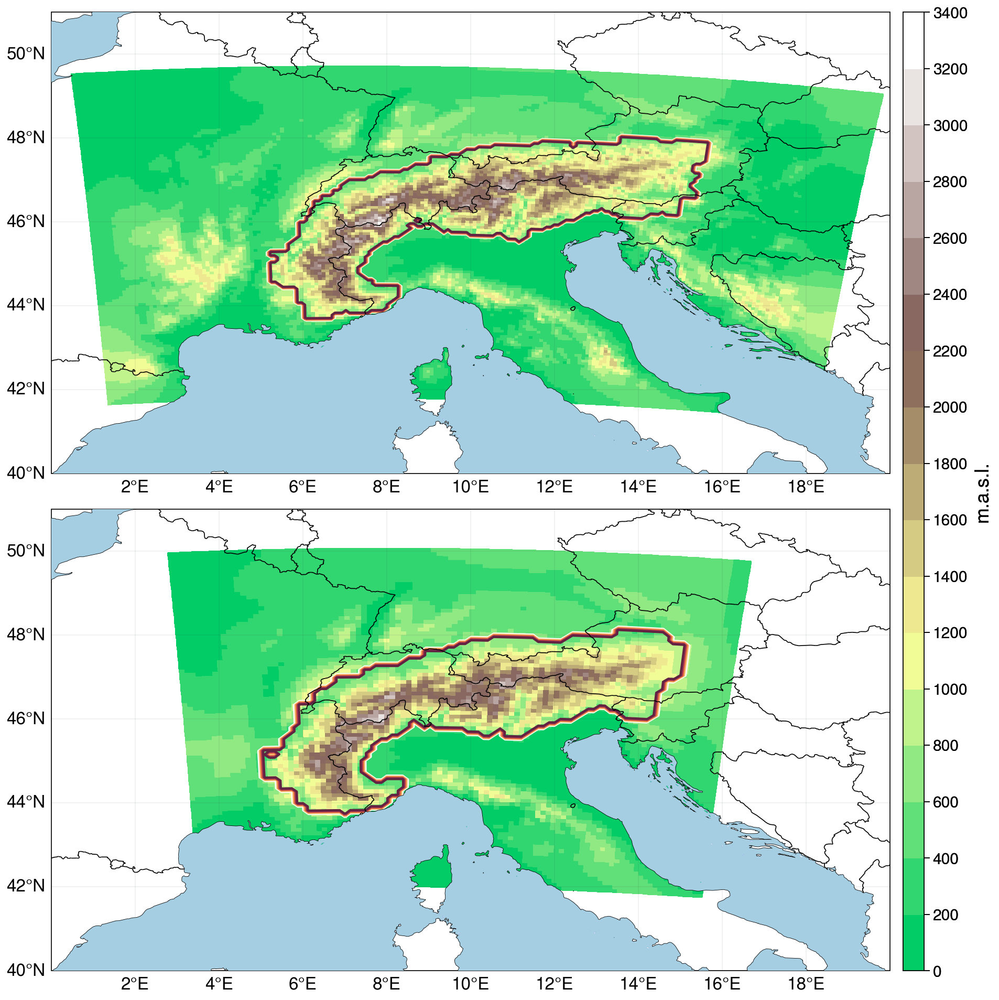

In [26]:
pplt.rc['figure.facecolor'] = 'white'

colors_land = plt.cm.terrain(np.linspace(0.25, 1, 256))
lvls_range = np.linspace(0,3400,18)

f, axs = pplt.subplots(proj='cyl', axwidth=8,nrows=2)

m=axs[1].pcolormesh(ds_smallish.LON, ds_smallish.LAT, ds_smallish.SH, levels=lvls_range,cmap=colors_land)
# axs[0].colorbar(m,label= 'm.a.s.l.',labelsize='x-large',ticklabelsize='large')
# axs[0].plot([4.,16.,16,4,4],[43.,43,48.5,48.5,43],'--r')
axs[1].contour(lon_smallish, lat_smallish, alps_smallish)

m=axs[0].pcolormesh(ds.LON, ds.LAT, ds.SH, levels=lvls_range,cmap=colors_land)
f.colorbar(m,label= 'm.a.s.l.',labelsize='x-large',ticklabelsize='large')
# axs[1].plot([4.,16.,16,4,4],[43.,43,48.5,48.5,43],'--r')
axs[0].contour(lon, lat, alps)

f.format(**normal_format)
f.format(ocean=True,oceancolor='royalblue',reso='hi', latlim=[40.,51.],lonlim=[0.,20.])
axs.add_feature(cfeature.OCEAN, facecolor='#a6cee3', zorder=3)
f.save("/summer/mar/castelli/figs/Manuscript/f00.png", dpi=300, bbox_inches='tight')

/home/castelli/.conda/envs/phd_v5/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


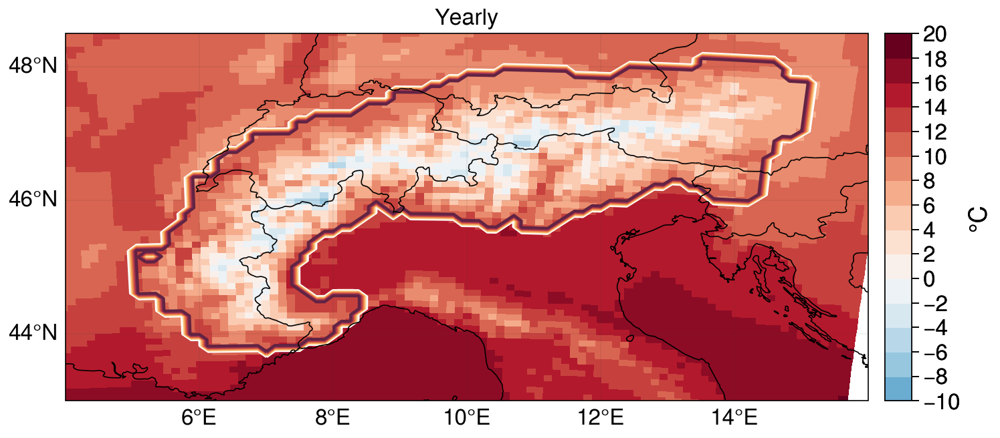

In [13]:
colmap = 'RdBu_r'

f, axs = pplt.subplots(proj='cyl',axwidth=6)

lvls_range = np.linspace(-10,20,16)

m = axs.pcolormesh(lon_smallish,lat_smallish,ds_2015.TTz.mean(dim='time'),levels=lvls_range,cmap=colmap)#,norm=norm)
axs.contour(lon_smallish, lat_smallish, alps_smallish)
axs.format(title='Yearly',titlesize='17px')

f.colorbar(m, label= '°C',labelsize='x-large')#,ticks=0.1)

axs.format(**normal_format)#,suptitle="Year",suptitlesize='16px')

/home/castelli/.conda/envs/phd_v5/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


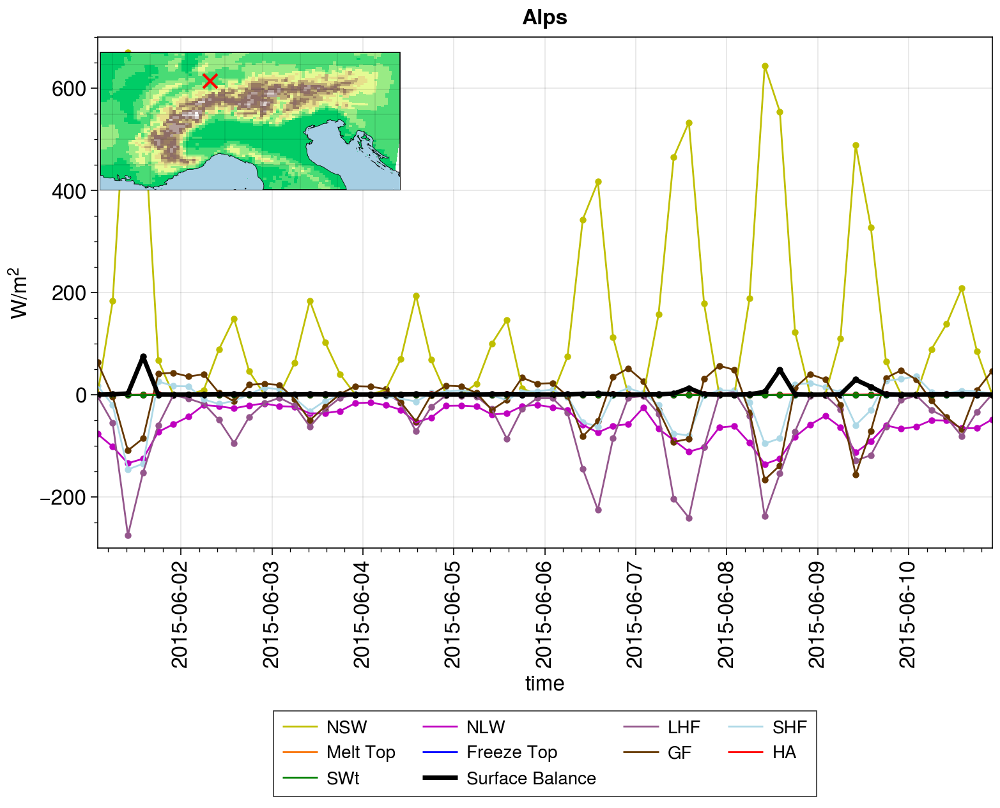

In [14]:
f, axs = pplt.subplots(axwidth=7,axheight=4)

names_var = ['NSW','NLW','LHF','SHF','melt','freeze','GF','HAcc','SWt','Surf_Bal']
names_propre = ['NSW','NLW','LHF','SHF','Melt Top','Freeze Top','GF','HA','SWt','Surface Balance']
colors = ['y','m','purple','lightblue','orange','blue','brown','r','green','k']
start = '2015-06-01'
end = '2015-06-10'
ymin, ymax = -300, 700
iloc, jloc = 59, 40

ds_ = ds_2015.sel(time=slice(start, end))

for i,var in enumerate(names_var):
    if(var=='Surf_Bal' or var=='Surf_Bal_HA_col' or var=='Surf_Bal_nofreeze' or var=='Surf_Bal_noHAcc'):
        line_width=2.5
    else:
        line_width=1
    ax=axs
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    ax.scatter(ds_.time, np.array(ds_[var][:,iloc, jloc]), c=colors[i], s=10)
    ax.plot(ds_.time, np.array(ds_[var][:,iloc, jloc]), c=colors[i],linewidth=line_width,label=names_propre[i])

# -----------------------------
# INSET AXIS (MAR topography)
# -----------------------------
cmap = ListedColormap(colors_land)

proj = ccrs.PlateCarree()
axins = f.add_axes([0.10, 0.70, 0.3, 0.3], projection=proj)
axins.set_extent([4, 16, 43, 48.5], crs=ccrs.PlateCarree())  # Alps domain
# axins.coastlines()

glins = axins.pcolormesh(
    ds_smallish.LON, ds_smallish.LAT, ds_smallish.SH,
    cmap=cmap,
    transform=ccrs.PlateCarree()
)
axins.plot(ds_smallish.LON[iloc,jloc], ds_smallish.LAT[iloc,jloc],'rx',markersize=8,markeredgewidth=1.5)
axins.coastlines()
axins.add_feature(cfeature.OCEAN, facecolor='#a6cee3', zorder=3)

f.format(titlesize='20px',suptitle='Alps')
f.legend(loc='b',prop = { "size": 10 },ncols=4)

In [15]:
path='/summer/mar/castelli/MAR-MPI-ESM/v3.14/STlim30/SSP585/ICE.MPI-ESM_SSP585'
simcode='m'
vars=['TTz','TTmin','TTmax','ST','LWD','LWU','SWD','SWU','SHF','LHF','GF','HAcc','SWt','MB','MBmTop','MBrTop']

ds_2015_lim30 = xr.open_dataset(path+'.EU'+simcode+'.'+vars[0]+'.'+str(2015)+'.nc').sel(ztqlev=2.0)#.resample(time='D').mean() # sel(ztqlev=2.0) bcse first variable is TTz

for var in vars[1:]:
    ds_var = xr.open_dataset(path+'.EU'+simcode+'.'+var+'.'+str(2015)+'.nc')#.resample(time='D').mean()
    ds_2015_lim30[var] = ds_var[var]

In [16]:
ds_2015_lim30 = ds_2015_lim30.isel(atmlay=0)

ds_2015_lim30 = computing_energy_bal(ds_in = ds_2015_lim30, ds_sect = ds_smallish, t_timestep = 60*60*4)

In [17]:
ds_2015_lim30_alps = ds_2015_lim30.where(alps_smallish).mean(dim=('x','y'))
ds_2015_lim30_alps

<xarray.Dataset>
Dimensions:   (time: 2190, sector: 3)
Coordinates:
  * time      (time) datetime64[ns] 2015-01-01T02:00:00 ... 2015-12-31T22:00:00
    ztqlev    float32 2.0
    atmlay    float32 0.9997
  * sector    (sector) float32 1.0 2.0 3.0
Data variables: (12/21)
    TTz       (time) float32 4.274 4.465 5.213 5.386 ... -0.2192 -1.542 -1.856
    TTmin     (time) float32 3.957 4.091 4.551 4.704 ... -1.074 -2.056 -2.205
    TTmax     (time) float32 4.766 4.916 5.846 5.871 ... 0.2532 -0.7992 -1.493
    ST        (time) float32 1.927 2.265 3.395 4.033 ... -2.015 -3.883 -4.604
    LWD       (time) float32 278.3 292.0 297.7 297.8 ... 273.9 269.3 265.9 264.2
    LWU       (time) float32 322.3 325.3 334.6 336.2 ... 308.7 309.0 295.9 293.5
    ...        ...
    MBrTop    (time, sector) float32 0.01993 0.03075 0.02361 ... 0.0401 0.002825
    NSW       (time) float32 0.0 0.1543 64.64 58.48 0.0 ... 65.4 59.25 0.0 0.0
    NLW       (time) float32 -44.03 -33.3 -36.87 -38.37 ... -39.69 -29.98 -29.29
    melt      (time) float32 -8.167 -7.595 -11.28 ... -5.266 -1.456 -1.642
    freeze    (time) float32 0.5075 0.2615 0.0928 0.3836 ... 0.9035 1.41 0.5135
    Surf_Bal  (time) float32 -0.09268 0.1071 0.2832 ... -0.06253 -0.07065

In [18]:
path='/summer/mar/castelli/MAR-MPI-ESM/v3.14/bigdomain/SSP585/ICE.MPI-ESM_SSP585'
simcode='n'
vars=['TTz','TTmin','TTmax','ST','LWD','LWU','SWD','SWU','SHF','LHF','GF','HAcc','SWt','MB','MBmTop','MBrTop']

ds_2015_7km = xr.open_dataset(path+'.EU'+simcode+'.'+vars[0]+'.'+str(2015)+'.nc').sel(ztqlev=2.0).isel(x=slice(imin,imax), y=slice(jmin,jmax))

for var in vars[1:]:
    ds_var = xr.open_dataset(path+'.EU'+simcode+'.'+var+'.'+str(2015)+'.nc')#.resample(time='D').mean()
    ds_2015_7km[var] = ds_var[var]

In [19]:
ds_2015_7km = ds_2015_7km.isel(atmlay=0)

ds_2015_7km = computing_energy_bal(ds_in = ds_2015_7km, ds_sect = ds_big, t_timestep = 60*60*24)

In [20]:
ds_2015_7km_alps = ds_2015_7km.where(alps).mean(dim=('x','y'))
ds_2015_7km_alps

<xarray.Dataset>
Dimensions:   (time: 365, sector: 3)
Coordinates:
  * time      (time) datetime64[ns] 2015-01-01T12:00:00 ... 2015-12-31T12:00:00
    atmlay    float32 0.9997
  * sector    (sector) float32 1.0 2.0 3.0
    ztqlev    float32 2.0
Data variables: (12/21)
    TTz       (time) float32 4.409 -2.469 -4.217 ... -3.784 -1.379 -1.039
    TTmin     (time) float32 2.049 -5.114 -6.574 -2.944 ... -7.896 -4.313 -2.753
    TTmax     (time) float32 6.023 2.392 -1.096 0.7864 ... 0.6017 0.5 0.4329
    ST        (time) float32 2.566 -2.809 -4.823 -2.101 ... -10.4 -3.796 -2.869
    LWD       (time) float32 292.3 268.6 251.6 271.6 ... 197.2 207.8 280.5 280.0
    LWU       (time) float32 327.5 301.7 292.4 305.0 ... 264.3 269.8 299.9 303.2
    ...        ...
    MBrTop    (time, sector) float32 0.1266 0.1724 0.108 ... 0.3133 0.06628
    NSW       (time) float32 18.98 18.79 28.33 22.31 ... 41.77 39.56 11.75 16.69
    NLW       (time) float32 -35.26 -33.1 -40.83 -33.39 ... -62.08 -19.43 -23.23
    melt      (time) float64 -8.843 -1.892 -0.7513 ... -0.6054 -2.656 -2.661
    freeze    (time) float64 0.4561 2.333 1.443 1.555 ... 0.2339 0.3667 0.7964
    Surf_Bal  (time) float64 0.1157 0.0165 0.04314 ... 0.0256 -0.05513 -0.003434

### Preparation of variables

#### Simulation with +10 limiter

In [113]:
first_year = 2015
last_year = 2025
path='/summer/mar/castelli/MAR-MPI-ESM/v3.14/SSP585/ICE.MPI-ESM_SSP585'

vars = ["TTz","TTmin","TTmax","ST","LWD","LWU","SWD","SWU",
    "SHF","LHF","GF","HAcc","SWt","MB","MBmTop","MBrTop"
]

monthly = []

for year in range(first_year, last_year + 1):

    print(year)

    ds = get_yrly_dataset(
        year,
        path=path,
        simcode="m",
        vars=vars,
    )

    ds = computing_energy_bal(ds, ds_sect = ds_smallish, t_timestep = 60*60*4)

    ds = ds.groupby("time.month").mean()

    ds = ds.expand_dims(Year=[year])

    monthly.append(ds)

ds_monthly = xr.concat(monthly, dim="Year")

2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


In [114]:
ds_monthly.to_netcdf("/summer/mar/castelli/saved_data_MAR_MPI_ESM1_2_HR/SSP585/smallishdomain/monthly_energy_balance_2015_2025.nc")

#### Simulation with +30 limiter

In [115]:
first_year = 2015
last_year = 2025
path='/summer/mar/castelli/MAR-MPI-ESM/v3.14/STlim30/SSP585/ICE.MPI-ESM_SSP585'

vars = ["TTz","TTmin","TTmax","ST","LWD","LWU","SWD","SWU",
    "SHF","LHF","GF","HAcc","SWt","MB","MBmTop","MBrTop"
]

monthly = []

for year in range(first_year, last_year + 1):

    print(year)

    ds = get_yrly_dataset(
        year,
        path=path,
        simcode="m",
        vars=vars,
    )

    ds = computing_energy_bal(ds, ds_sect = ds_smallish, t_timestep = 60*60*4)

    ds = ds.groupby("time.month").mean()

    ds = ds.expand_dims(Year=[year])

    monthly.append(ds)

ds_monthly = xr.concat(monthly, dim="Year")

2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


In [116]:
ds_monthly.to_netcdf("/summer/mar/castelli/saved_data_MAR_MPI_ESM1_2_HR/SSP585/smallishdomain/STlim30/monthly_energy_balance_2015_2025.nc")

#### Simulation at 7 km with no limiter

In [50]:
first_year = 2015
last_year = 2025
path='/summer/mar/castelli/MAR-MPI-ESM/v3.14/bigdomain/SSP585/ICE.MPI-ESM_SSP585'

vars = ["TTz","TTmin","TTmax","ST","LWD","LWU","SWD","SWU",
    "SHF","LHF","GF","HAcc","SWt","MB","MBmTop","MBrTop"
]

monthly = []

for year in range(first_year, last_year + 1):

    print(year)

    ds = get_yrly_dataset(
        year,
        path=path,
        simcode="n",
        vars=vars,
    )

    ds = computing_energy_bal(ds, ds_sect = ds_big, t_timestep = 60*60*24)

    ds = ds.groupby("time.month").mean()

    ds = ds.expand_dims(Year=[year])

    monthly.append(ds)

ds_monthly = xr.concat(monthly, dim="Year")

2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


In [70]:
ds_monthly.to_netcdf("/summer/mar/castelli/saved_data_MAR_MPI_ESM1_2_HR/SSP585/monthly_energy_balance_2015_2025.nc")

### Loading prepared variables

In [21]:
path = '/summer/mar/castelli/saved_data_MAR_MPI_ESM1_2_HR/SSP585/smallishdomain/'
ds_monthly = xr.open_dataset(path + 'monthly_energy_balance_2015_2025.nc')

print(ds_monthly)

<xarray.Dataset>
Dimensions:   (Year: 11, month: 12, y: 90, x: 100, atmlay: 2, sector: 3)
Coordinates:
  * Year      (Year) int64 2015 2016 2017 2018 2019 ... 2021 2022 2023 2024 2025
  * x         (x) float32 -370.0 -360.0 -350.0 -340.0 ... 600.0 610.0 620.0
  * y         (y) float32 -440.0 -430.0 -420.0 -410.0 ... 430.0 440.0 450.0
    ztqlev    float32 ...
  * atmlay    (atmlay) float32 0.9997 0.9995
  * sector    (sector) float32 1.0 2.0 3.0
  * month     (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/21)
    TTz       (Year, month, y, x) float32 ...
    TTmin     (Year, month, atmlay, y, x) float32 ...
    TTmax     (Year, month, atmlay, y, x) float32 ...
    ST        (Year, month, y, x) float32 ...
    LWD       (Year, month, y, x) float32 ...
    LWU       (Year, month, y, x) float32 ...
    ...        ...
    MBrTop    (Year, month, sector, y, x) float32 ...
    NSW       (Year, month, y, x) float32 ...
    NLW       (Year, month, y, x) float32 ...
    melt      

In [22]:
path = '/summer/mar/castelli/saved_data_MAR_MPI_ESM1_2_HR/SSP585/smallishdomain/STlim30/'
ds_monthly_lim30 = xr.open_dataset(path + 'monthly_energy_balance_2015_2025.nc')

In [23]:
path = '/summer/mar/castelli/saved_data_MAR_MPI_ESM1_2_HR/SSP585/'
ds_monthly_7km = xr.open_dataset(path + 'monthly_energy_balance_2015_2025.nc').isel(x=slice(imin,imax), y=slice(jmin,jmax))

print(ds_monthly_7km)

<xarray.Dataset>
Dimensions:   (Year: 11, month: 12, y: 91, x: 139, atmlay: 2, sector: 3)
Coordinates:
  * Year      (Year) int64 2015 2016 2017 2018 2019 ... 2021 2022 2023 2024 2025
  * x         (x) float32 -259.0 -252.0 -245.0 -238.0 ... 693.0 700.0 707.0
  * y         (y) float32 -168.0 -161.0 -154.0 -147.0 ... 448.0 455.0 462.0
    ztqlev    float32 ...
  * atmlay    (atmlay) float32 0.9997 0.9995
  * sector    (sector) float32 1.0 2.0 3.0
  * month     (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/21)
    TTz       (Year, month, y, x) float32 ...
    TTmin     (Year, month, atmlay, y, x) float32 ...
    TTmax     (Year, month, atmlay, y, x) float32 ...
    ST        (Year, month, y, x) float32 ...
    LWD       (Year, month, y, x) float32 ...
    LWU       (Year, month, y, x) float32 ...
    ...        ...
    MBrTop    (Year, month, sector, y, x) float32 ...
    NSW       (Year, month, y, x) float32 ...
    NLW       (Year, month, y, x) float32 ...
    melt      

In [24]:
ds_monthly_alps = ds_monthly.where(alps_smallish).mean(dim=('x','y'))
ds_monthly_lim30_alps = ds_monthly_lim30.where(alps_smallish).mean(dim=('x','y'))
ds_monthly_7km_alps = ds_monthly_7km.where(alps).mean(dim=('x','y'))

ds_monthly_alps

<xarray.Dataset>
Dimensions:   (Year: 11, month: 12, atmlay: 2, sector: 3)
Coordinates:
  * Year      (Year) int64 2015 2016 2017 2018 2019 ... 2021 2022 2023 2024 2025
    ztqlev    float32 ...
  * atmlay    (atmlay) float32 0.9997 0.9995
  * sector    (sector) float32 1.0 2.0 3.0
  * month     (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/21)
    TTz       (Year, month) float32 -3.645 -3.407 -0.8135 ... 0.6727 0.1581
    TTmin     (Year, month, atmlay) float32 -4.513 -4.379 ... -0.6454 -0.5142
    TTmax     (Year, month, atmlay) float32 -2.879 -2.852 ... 0.9365 0.9774
    ST        (Year, month) float32 -5.488 -4.759 -1.861 ... -0.6693 -1.827
    LWD       (Year, month) float32 252.9 254.9 270.9 ... 301.6 271.9 268.6
    LWU       (Year, month) float32 290.6 293.6 307.1 ... 345.4 310.7 306.5
    ...        ...
    MBrTop    (Year, month, sector) float32 0.05692 0.04782 ... 0.05411 0.0111
    NSW       (Year, month) float32 27.97 39.13 58.93 ... 60.23 33.21 22.27
    NLW       (Year, month) float32 -37.7 -38.68 -36.27 ... -43.84 -38.72 -37.87
    melt      (Year, month) float32 -2.61 -1.61 -3.92 ... -1.031 -2.767 -3.597
    freeze    (Year, month) float32 0.675 0.7847 0.4992 ... 0.1759 0.4431 0.7993
    Surf_Bal  (Year, month) float32 -0.07742 0.008427 ... 0.01254 -0.0001509

In [25]:
names_months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

ds_monthly_alps = ds_monthly_alps.assign_coords(month=("month", names_months))
ds_monthly_lim30_alps = ds_monthly_lim30_alps.assign_coords(month=("month", names_months))
ds_monthly_7km_alps = ds_monthly_7km_alps.assign_coords(month=("month", names_months))

ds_monthly_alps

<xarray.Dataset>
Dimensions:   (Year: 11, month: 12, atmlay: 2, sector: 3)
Coordinates:
  * Year      (Year) int64 2015 2016 2017 2018 2019 ... 2021 2022 2023 2024 2025
    ztqlev    float32 ...
  * atmlay    (atmlay) float32 0.9997 0.9995
  * sector    (sector) float32 1.0 2.0 3.0
  * month     (month) <U3 'Jan' 'Feb' 'Mar' 'Apr' ... 'Sep' 'Oct' 'Nov' 'Dec'
Data variables: (12/21)
    TTz       (Year, month) float32 -3.645 -3.407 -0.8135 ... 0.6727 0.1581
    TTmin     (Year, month, atmlay) float32 -4.513 -4.379 ... -0.6454 -0.5142
    TTmax     (Year, month, atmlay) float32 -2.879 -2.852 ... 0.9365 0.9774
    ST        (Year, month) float32 -5.488 -4.759 -1.861 ... -0.6693 -1.827
    LWD       (Year, month) float32 252.9 254.9 270.9 ... 301.6 271.9 268.6
    LWU       (Year, month) float32 290.6 293.6 307.1 ... 345.4 310.7 306.5
    ...        ...
    MBrTop    (Year, month, sector) float32 0.05692 0.04782 ... 0.05411 0.0111
    NSW       (Year, month) float32 27.97 39.13 58.93 ... 60.23 33.21 22.27
    NLW       (Year, month) float32 -37.7 -38.68 -36.27 ... -43.84 -38.72 -37.87
    melt      (Year, month) float32 -2.61 -1.61 -3.92 ... -1.031 -2.767 -3.597
    freeze    (Year, month) float32 0.675 0.7847 0.4992 ... 0.1759 0.4431 0.7993
    Surf_Bal  (Year, month) float32 -0.07742 0.008427 ... 0.01254 -0.0001509

[Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, '')]


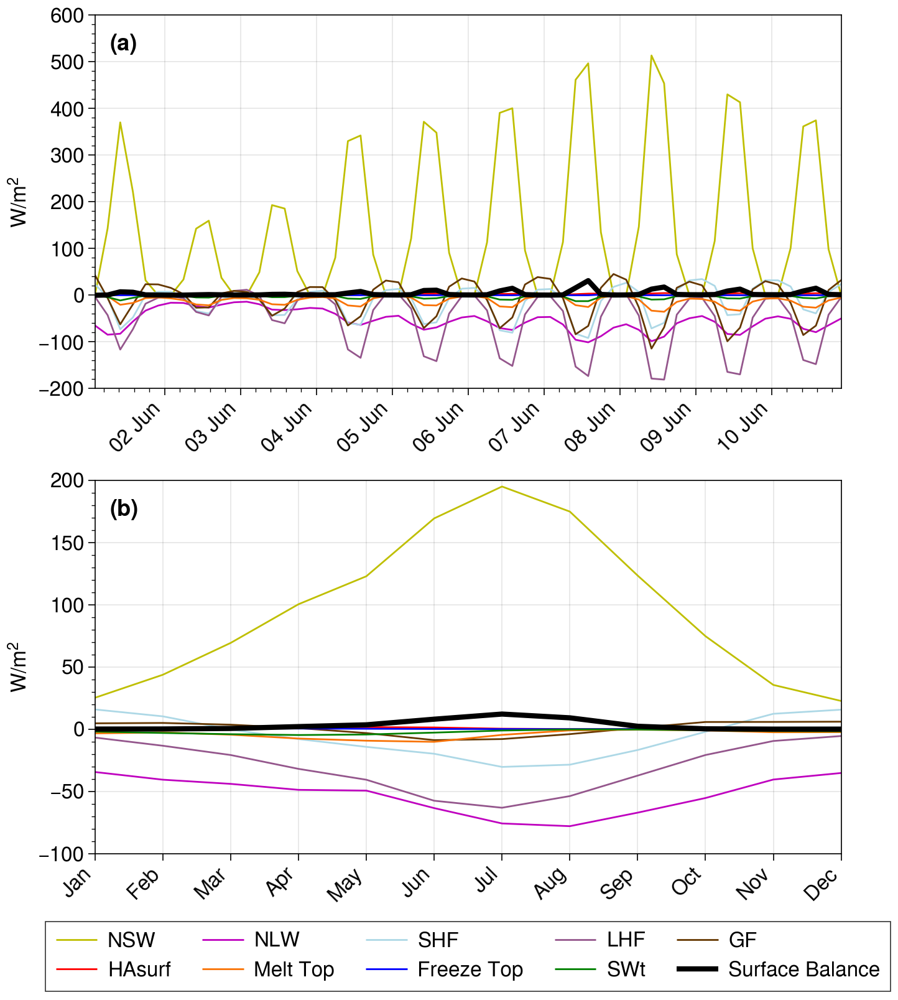

In [124]:
# ------------- Subplot (a) ----------------
# averaged over the alps so link between high NSW and high surf_bal is maybe less visible

f, axs = pplt.subplots(nrows=2,axwidth=6,axheight=3,sharex=False,sharey=False)

names_var = ['NSW','NLW','SHF','LHF','GF','HAcc','melt','freeze','SWt','Surf_Bal']
names_propre = ['NSW','NLW','SHF','LHF','GF','HAsurf','Melt Top','Freeze Top','SWt','Surface Balance']
colors = ['y','m','lightblue','purple','brown','r','orange','blue','green','k']
start = '2015-06-01'
end = '2015-06-10'
ymin, ymax = -200, 600

ds_ = ds_2015_alps.sel(time=slice(start, end))

for i,var in enumerate(names_var):
    if(var=='Surf_Bal' or var=='Surf_Bal_HA_col' or var=='Surf_Bal_nofreeze' or var=='Surf_Bal_noHAcc'):
        line_width = 3
        size_marker = 15
    else:
        line_width=1
        size_marker = 10
    ax=axs[0]
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    # ax.scatter(ds_.time, ds_[var], c=colors[i], s=size_marker)
    ax.plot(ds_.time, ds_[var], c=colors[i],linewidth=line_width)

# ------------- Subplot (b) ----------------
# averaged over the alps

start = '2015'
end = '2025'
ymin, ymax = -100, 200

ds_ = ds_monthly_alps.sel(Year=slice(start, end)).mean(dim="Year")

for i,var in enumerate(names_var):
    if(var=='Surf_Bal' or var=='Surf_Bal_HA_col' or var=='Surf_Bal_nofreeze' or var=='Surf_Bal_noHAcc'):
        line_width=3
        size_marker = 15
    else:
        line_width=1
        size_marker = 10
    ax=axs[1]
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    # ax.scatter(ds_.month, ds_[var], c=colors[i], s=size_marker)
    ax.plot(ds_.month, ds_[var], c=colors[i],linewidth=line_width,label=names_propre[i])


# Axes and legend
axs.format(xlabel='')

from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0],
           color=colors[i],
           lw=3 if names_var[i]=='Surf_Bal' else 1,
           # marker='o',
           # markersize=4,
           label=names_propre[i])
    for i in range(len(names_var))
]

f.legend(handles=handles, loc='b', ncols=5)

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

# Set tick labels
axs[0].format(
    xformatter='%d %b',
    xrotation=45,
)

ax.set_xticks(np.arange(0, 12))
ax.set_xticklabels(names_months, rotation=45, ha='right')

print(axs[0].get_xticklabels())
f.save("/summer/mar/castelli/figs/Manuscript/f01.png", dpi=300, bbox_inches='tight')

[Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, '')]


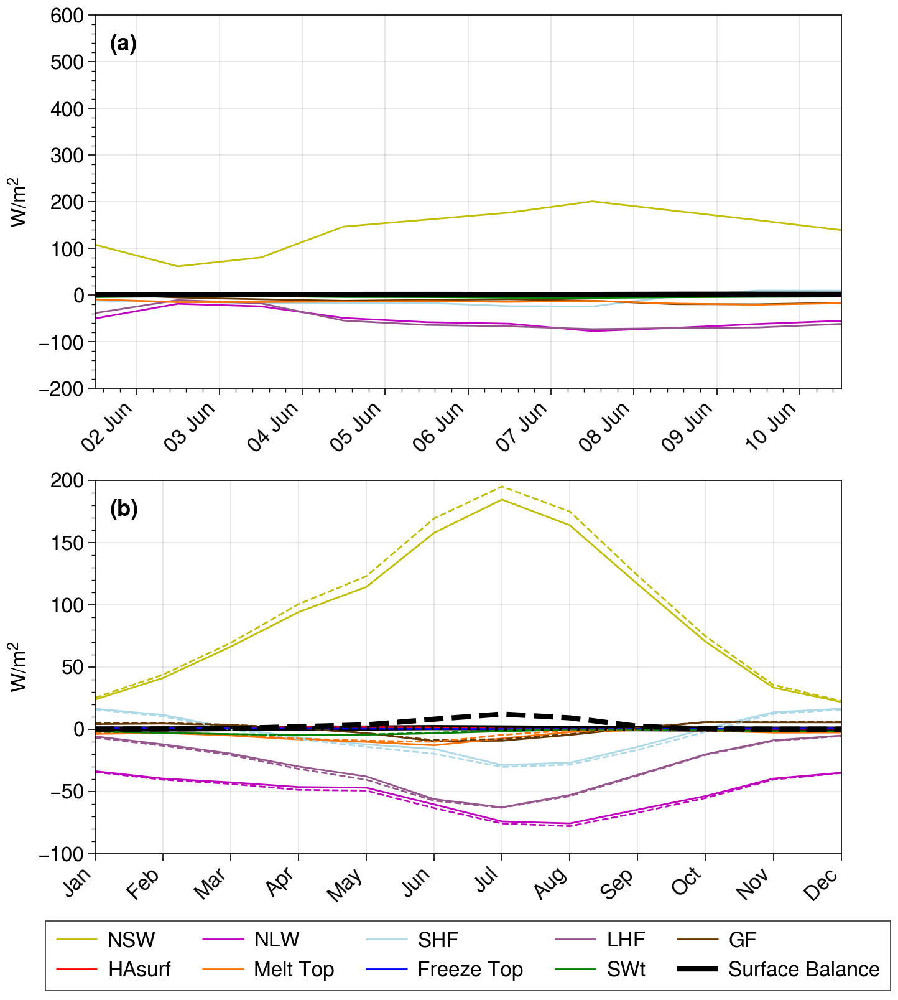

In [125]:
# ------------- Subplot (a) ----------------
# averaged over the alps so link between high NSW and high surf_bal is maybe less visible

f, axs = pplt.subplots(nrows=2,axwidth=6,axheight=3,sharex=False,sharey=False)

names_var = ['NSW','NLW','SHF','LHF','GF','HAcc','melt','freeze','SWt','Surf_Bal']
names_propre = ['NSW','NLW','SHF','LHF','GF','HAsurf','Melt Top','Freeze Top','SWt','Surface Balance']
colors = ['y','m','lightblue','purple','brown','r','orange','blue','green','k']
start = '2015-06-01'
end = '2015-06-10'
ymin, ymax = -200, 600

ds_ = ds_2015_7km_alps.sel(time=slice(start, end))

for i,var in enumerate(names_var):
    if(var=='Surf_Bal' or var=='Surf_Bal_HA_col' or var=='Surf_Bal_nofreeze' or var=='Surf_Bal_noHAcc'):
        line_width = 3
        size_marker = 15
    else:
        line_width=1
        size_marker = 10
    ax=axs[0]
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    # ax.scatter(ds_.time, ds_[var], c=colors[i], s=size_marker)
    ax.plot(ds_.time, ds_[var], c=colors[i],linewidth=line_width)

# ------------- Subplot (b) ----------------
# averaged over the alps

start = '2015'
end = '2025'
ymin, ymax = -100, 200

ds_ = ds_monthly_7km_alps.sel(Year=slice(start, end)).mean(dim="Year")

for i,var in enumerate(names_var):
    if(var=='Surf_Bal' or var=='Surf_Bal_HA_col' or var=='Surf_Bal_nofreeze' or var=='Surf_Bal_noHAcc'):
        line_width=3
        size_marker = 15
    else:
        line_width=1
        size_marker = 10
    ax=axs[1]
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    # ax.scatter(ds_.month, ds_[var], c=colors[i], s=size_marker)
    ax.plot(ds_.month, ds_[var], c=colors[i],linewidth=line_width,label=names_propre[i])


# Axes and legend
axs.format(xlabel='')

from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0],
           color=colors[i],
           lw=3 if names_var[i]=='Surf_Bal' else 1,
           # marker='o',
           # markersize=4,
           label=names_propre[i])
    for i in range(len(names_var))
]

# --- dashed --- 

# ------------- Subplot (b) ----------------
# averaged over the alps

start = '2015'
end = '2025'
ymin, ymax = -100, 200

ds_ = ds_monthly_alps.sel(Year=slice(start, end)).mean(dim="Year")

for i,var in enumerate(names_var):
    if(var=='Surf_Bal' or var=='Surf_Bal_HA_col' or var=='Surf_Bal_nofreeze' or var=='Surf_Bal_noHAcc'):
        line_width=3
        size_marker = 15
    else:
        line_width=1
        size_marker = 10
    ax=axs[1]
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    # ax.scatter(ds_.month, ds_[var], c=colors[i], s=size_marker)
    ax.plot(ds_.month, ds_[var], c=colors[i],linewidth=line_width, linestyle='--')

# --- /dashed ---

f.legend(handles=handles, loc='b', ncols=5)

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

# Set tick labels
axs[0].format(
    xformatter='%d %b',
    xrotation=45,
)

ax.set_xticks(np.arange(0, 12))
ax.set_xticklabels(names_months, rotation=45, ha='right')

print(axs[0].get_xticklabels())
#f.save("/summer/mar/castelli/figs/Manuscript/f01.png", dpi=300, bbox_inches='tight')

[Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, '')]


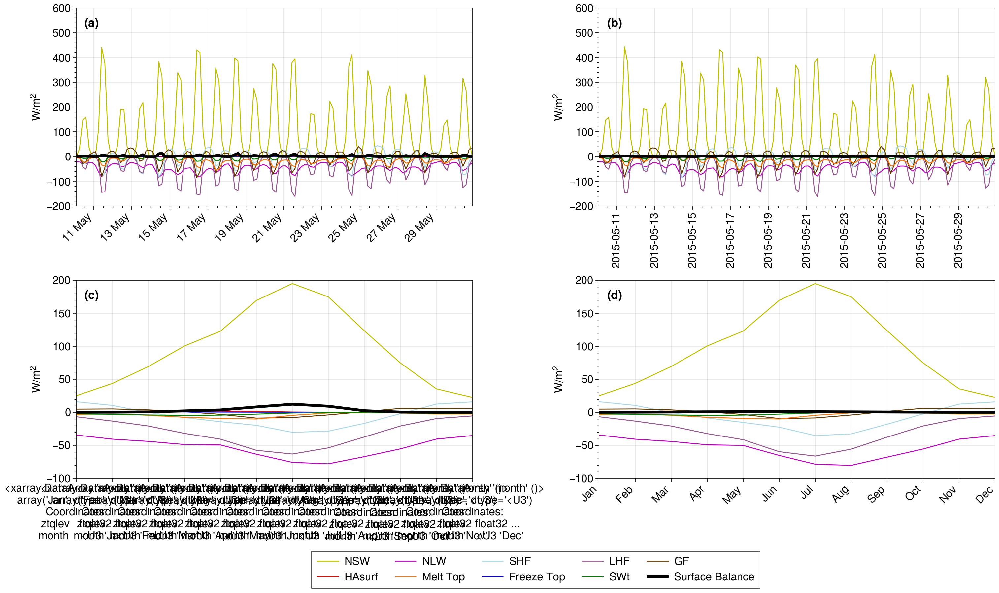

In [126]:
# ------------- Subplot (a) ----------------
# averaged over the alps so link between high NSW and high surf_bal is maybe less visible

f, axs = pplt.subplots(nrows=2,ncols=2,axwidth=6,axheight=3,sharex=False,sharey=False)

names_var = ['NSW','NLW','SHF','LHF','GF','HAcc','melt','freeze','SWt','Surf_Bal']
names_propre = ['NSW','NLW','SHF','LHF','GF','HAsurf','Melt Top','Freeze Top','SWt','Surface Balance']
colors = ['y','m','lightblue','purple','brown','r','orange','blue','green','k']
start = '2015-05-10'
end = '2015-05-30'
ymin, ymax = -200, 600

ds_ = ds_2015_lim30_alps.sel(time=slice(start, end))

for i,var in enumerate(names_var):
    if(var=='Surf_Bal' or var=='Surf_Bal_HA_col' or var=='Surf_Bal_nofreeze' or var=='Surf_Bal_noHAcc'):
        line_width = 3
        size_marker = 15
    else:
        line_width=1
        size_marker = 10
    ax=axs[1]
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    # ax.scatter(ds_.time, ds_[var], c=colors[i], s=size_marker)
    ax.plot(ds_.time, ds_[var], c=colors[i],linewidth=line_width)

# ------------- Subplot (a) ----------------
# averaged over the alps so link between high NSW and high surf_bal is maybe less visible

ds_ = ds_2015_alps.sel(time=slice(start, end))

for i,var in enumerate(names_var):
    if(var=='Surf_Bal' or var=='Surf_Bal_HA_col' or var=='Surf_Bal_nofreeze' or var=='Surf_Bal_noHAcc'):
        line_width = 3
        size_marker = 15
    else:
        line_width=1
        size_marker = 10
    ax=axs[0]
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    # ax.scatter(ds_.time, ds_[var], c=colors[i], s=size_marker)
    ax.plot(ds_.time, ds_[var], c=colors[i],linewidth=line_width)

# ------------- Subplot (b) ----------------
# averaged over the alps

start = '2015'
end = '2025'
ymin, ymax = -100, 200

ds_ = ds_monthly_lim30_alps.sel(Year=slice(start, end)).mean(dim="Year")

for i,var in enumerate(names_var):
    if(var=='Surf_Bal' or var=='Surf_Bal_HA_col' or var=='Surf_Bal_nofreeze' or var=='Surf_Bal_noHAcc'):
        line_width=3
        size_marker = 15
    else:
        line_width=1
        size_marker = 10
    ax=axs[3]
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    # ax.scatter(ds_.month, ds_[var], c=colors[i], s=size_marker)
    ax.plot(ds_.month, ds_[var], c=colors[i],linewidth=line_width,label=names_propre[i])


# Axes and legend
axs.format(xlabel='')

# ------------- Subplot (b) ----------------
# averaged over the alps

start = '2015'
end = '2025'
ymin, ymax = -100, 200

ds_ = ds_monthly_alps.sel(Year=slice(start, end)).mean(dim="Year")

for i,var in enumerate(names_var):
    if(var=='Surf_Bal' or var=='Surf_Bal_HA_col' or var=='Surf_Bal_nofreeze' or var=='Surf_Bal_noHAcc'):
        line_width=3
        size_marker = 15
    else:
        line_width=1
        size_marker = 10
    ax=axs[2]
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    # ax.scatter(ds_.month, ds_[var], c=colors[i], s=size_marker)
    ax.plot(ds_.month, ds_[var], c=colors[i],linewidth=line_width,label=names_propre[i])


from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0],
           color=colors[i],
           lw=3 if names_var[i]=='Surf_Bal' else 1,
           # marker='o',
           # markersize=4,
           label=names_propre[i])
    for i in range(len(names_var))
]

f.legend(handles=handles, loc='b', ncols=5)

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

# Set tick labels
axs[0].format(
    xformatter='%d %b',
    xrotation=45,
)

ax.set_xticks(np.arange(0, 12))
ax.set_xticklabels(names_months, rotation=45, ha='right')

print(axs[0].get_xticklabels())

### Final figures

[Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, '')]


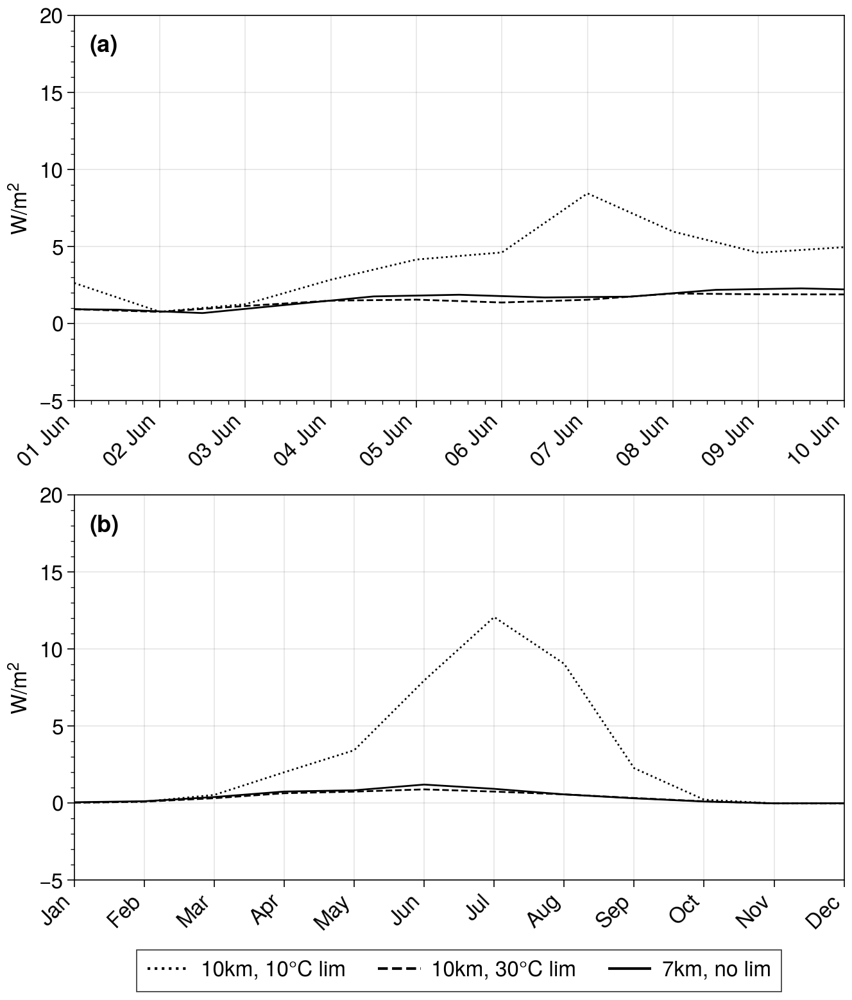

In [127]:
# ------------- Subplot (a) ----------------
# averaged over the alps so link between high NSW and high surf_bal is maybe less visible

f, axs = pplt.subplots(nrows=2,axwidth=6,axheight=3,sharex=False,sharey=False)

# names_var = ['NSW','NLW','SHF','LHF','GF','HAcc','melt','freeze','SWt','Surf_Bal']
# names_propre = ['NSW','NLW','SHF','LHF','GF','HAsurf','Melt Top','Freeze Top','SWt','Surface Balance']
# colors = ['y','m','lightblue','purple','brown','r','orange','blue','green','k']
names = ['10km, 10°C lim','10km, 30°C lim','7km, no lim']
linestyles = [':','--','-']
start = '2015-06-01'
end = '2015-06-10'
ymin, ymax = -5, 20

ds_1 = ds_2015_alps.sel(time=slice(start, end)).resample(time='1D').mean()
ds_2 = ds_2015_lim30_alps.sel(time=slice(start, end)).resample(time='1D').mean()
ds_3 = ds_2015_7km_alps.sel(time=slice('2015-05-31', '2015-06-11'))
list_ds = [ds_1,ds_2,ds_3]

for i,ds_ in enumerate(list_ds):
    ax=axs[0]
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    # ax.scatter(ds_.time, ds_[var], c=colors[i], s=size_marker)
    ax.plot(ds_.time, ds_['Surf_Bal'], c='k', linewidth=1, linestyle=linestyles[i])

ax.set_xlim(np.datetime64('2015-06-01'),
            np.datetime64('2015-06-10'))
# ------------- Subplot (b) ----------------
# averaged over the alps

start = '2015'
end = '2025'
ymin, ymax = -5, 20

ds_1 = ds_monthly_alps.sel(Year=slice(start, end)).mean(dim="Year")
ds_2 = ds_monthly_lim30_alps.sel(Year=slice(start, end)).mean(dim="Year")
ds_3 = ds_monthly_7km_alps.sel(Year=slice(start, end)).mean(dim="Year")
list_ds = [ds_1,ds_2,ds_3]

for i,ds_ in enumerate(list_ds):
    ax=axs[1]
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    # ax.scatter(ds_.month, ds_[var], c=colors[i], s=size_marker)
    ax.plot(ds_.month, ds_['Surf_Bal'], c='k',linewidth=1,linestyle=linestyles[i],label=names[i])


# Axes and legend
axs.format(xlabel='')

from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0],
           color='k',
           linestyle=linestyles[i],
           # lw=3 if names_var[i]=='Surf_Bal' else 1,
           # marker='o',
           # markersize=4,
           label=names[i])
    for i in range(len(names))
]

f.legend(handles=handles, loc='b', ncols=3)

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

# Set tick labels
axs[0].format(
    xformatter='%d %b',
    xrotation=45,
)

ax.set_xticks(np.arange(0, 12))
ax.set_xticklabels(names_months, rotation=45, ha='right')

print(axs[0].get_xticklabels())
f.save("/summer/mar/castelli/figs/Manuscript/f02_test.png", dpi=300, bbox_inches='tight')

[Text(0, 0, 'Jan'), Text(1, 0, 'Feb'), Text(2, 0, 'Mar'), Text(3, 0, 'Apr'), Text(4, 0, 'May'), Text(5, 0, 'Jun'), Text(6, 0, 'Jul'), Text(7, 0, 'Aug'), Text(8, 0, 'Sep'), Text(9, 0, 'Oct'), Text(10, 0, 'Nov'), Text(11, 0, 'Dec')]


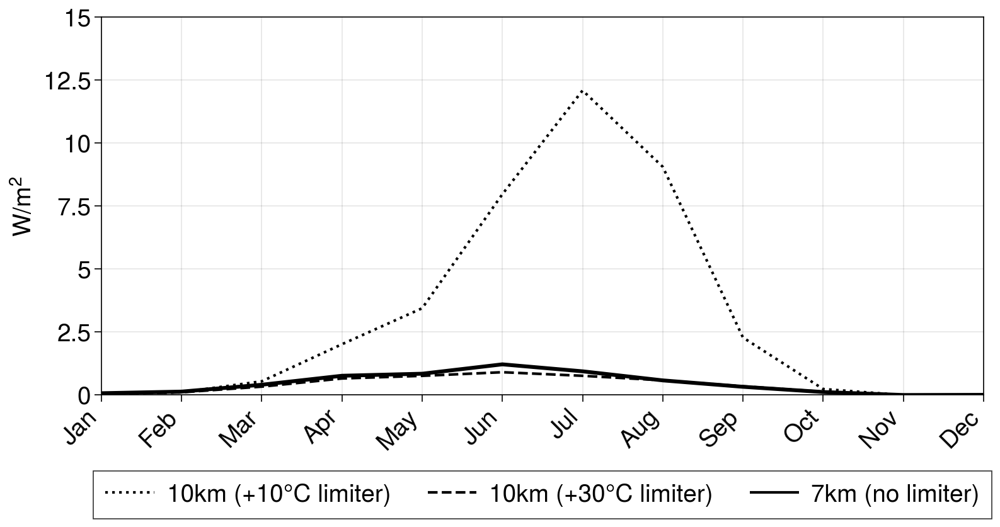

In [143]:
f, ax = pplt.subplots(axwidth=7,axheight=3)

# averaged over the alps
names = ['10km (+10°C limiter)','10km (+30°C limiter)','7km (no limiter)']
linestyles = [':','--','-']
linewidths = [1.5,1.5,2.2]
start = '2015'
end = '2025'
ymin, ymax = 0, 15

ds_1 = ds_monthly_alps.sel(Year=slice(start, end)).mean(dim="Year")
ds_2 = ds_monthly_lim30_alps.sel(Year=slice(start, end)).mean(dim="Year")
ds_3 = ds_monthly_7km_alps.sel(Year=slice(start, end)).mean(dim="Year")
list_ds = [ds_1,ds_2,ds_3]

for i,ds_ in enumerate(list_ds):
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    # ax.scatter(ds_.month, ds_[var], c=colors[i], s=size_marker)
    ax.plot(ds_.month, ds_['Surf_Bal'], c='k',linewidth=linewidths[i],linestyle=linestyles[i],label=names[i])


# Axes and legend
ax.format(xlabel='')
# ax.set_xlim(np.datetime64('2015-06-01'),
#             np.datetime64('2015-06-10'))

from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0],
           color='k',
           linestyle=linestyles[i],
           # lw=3 if names_var[i]=='Surf_Bal' else 1,
           # marker='o',
           # markersize=4,
           label=names[i])
    for i in range(len(names))
]

# ax.legend(handles=handles, loc='upper right', ncols=3)
f.legend(handles=handles, loc='b', ncols=3)

# Set tick labels
ax.format(
    xformatter='%d %b',
    xrotation=45,
)

ax.set_xticks(np.arange(0, 12))
ax.set_xticklabels(names_months, rotation=45, ha='right')
ax.minorticks_off()

print(ax.get_xticklabels())
f.save("/summer/mar/castelli/figs/Manuscript/f02.png", dpi=300, bbox_inches='tight')

### Climatologies

#### Loading/preprocessing data

In [13]:
def build_seasonal_dataset(
        path,
        years,
        variables,
        t_timestep,
        simcode,
        ds_sect=None,
        compute_energy_balance=True
):
    seasonal = []

    for year in years:
        print(year,end=" ")
        ds = get_yrly_dataset(year, path, simcode, variables)
    
        if compute_energy_balance:
            ds = computing_energy_bal(ds, ds_sect, t_timestep)

        ds = (
            ds
            .groupby("time.season")
            .mean("time")
            .load()
        )

        ds = ds.expand_dims(Year=[year])

        seasonal.append(ds)

    return xr.concat(seasonal, dim="Year")

In [131]:
path10 = '/summer/mar/castelli/MAR-MPI-ESM/v3.14/SSP585/ICE.MPI-ESM_SSP585'

path7 = '/summer/mar/castelli/MAR-MPI-ESM/v3.14/bigdomain/SSP585/ICE.MPI-ESM_SSP585'

years = range(2015,2101)

vars = ["TTz","TTmin","TTmax","ST","LWD","LWU","SWD","SWU",
        "SHF","LHF","GF","HAcc","SWt","MB","MBmTop","MBrTop"]


In [ ]:
ds_sect = ds_smallish
ds10 = build_seasonal_dataset(path=path10, years=years, variables=vars, t_timestep = 60*60*4, simcode='m', ds_sect=ds_sect)

In [ ]:
ds10.to_netcdf("/summer/mar/castelli/saved_data_MAR_MPI_ESM1_2_HR/SSP585/smallishdomain/seasonal_vars_energy_temp_2015_2100.nc")


In [22]:


ds_sect = ds_big
ds7 = build_seasonal_dataset(path=path7, years=years, variables=vars, simcode='n', ds_sect=ds_sect)

2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045 2046 2047 2048 2049 2050 2051 2052 2053 2054 2055 2056 2057 2058 2059 2060 2061 2062 2063 2064 2065 2066 2067 2068 2069 2070 2071 2072 2073 2074 2075 2076 2077 2078 2079 2080 2081 2082 2083 2084 2085 2086 2087 2088 2089 2090 2091 2092 2093 2094 2095 2096 2097 2098 2099 2100 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045 2046 2047 2048 2049 2050 2051 2052 2053 2054 2055 2056 2057 2058 2059 2060 2061 2062 2063 2064 2065 2066 2067 2068 2069 2070 2071 2072 2073 2074 2075 2076 2077 2078 2079 2080 2081 2082 2083 2084 2085 2086 2087 2088 2089 2090 2091 2092 2093 2094 2095 2096 2097 2098 2099 2100 

In [23]:
ds7

<xarray.Dataset>
Dimensions:   (Year: 86, season: 4, y: 126, x: 201, atmlay: 2, sector: 3)
Coordinates:
  * Year      (Year) int64 2015 2016 2017 2018 2019 ... 2096 2097 2098 2099 2100
  * x         (x) float32 -483.0 -476.0 -469.0 -462.0 ... 903.0 910.0 917.0
  * y         (y) float32 -308.0 -301.0 -294.0 -287.0 ... 553.0 560.0 567.0
    ztqlev    float32 2.0
  * atmlay    (atmlay) float32 0.9997 0.9995
  * sector    (sector) float32 1.0 2.0 3.0
  * season    (season) object 'DJF' 'JJA' 'MAM' 'SON'
Data variables: (12/21)
    TTz       (Year, season, y, x) float32 4.883 5.011 5.179 ... 12.35 12.34
    TTmin     (Year, season, atmlay, y, x) float32 1.812 1.975 ... 8.632 8.624
    TTmax     (Year, season, atmlay, y, x) float32 6.285 6.381 ... 14.51 14.5
    ST        (Year, season, y, x) float32 0.0 23.78 23.83 ... 24.58 24.55 0.0
    LWD       (Year, season, y, x) float32 0.0 243.5 244.0 ... 283.1 283.1 0.0
    LWU       (Year, season, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...        ...
    MBrTop    (Year, season, sector, y, x) float32 0.0 0.0 0.0 ... 0.0 0.0 0.0
    NSW       (Year, season, y, x) float32 0.0 96.37 96.31 ... 125.6 125.7 0.0
    NLW       (Year, season, y, x) float32 0.0 243.5 244.0 ... 283.1 283.1 0.0
    melt      (Year, season, y, x) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    freeze    (Year, season, y, x) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    Surf_Bal  (Year, season, y, x) float64 0.0 339.8 340.3 ... 408.8 408.7 0.0
Attributes:
    title:        ICE - Exp: n21 - 20150101
    institution:  ULg (Xavier Fettweis)
    history:      Thu Aug 21 10:31:40 2025: ncks -v TTz /bettik/castelli/MARo...
    netcdf:       4.8.0 of May  2 2023 12:43:48 $
    NCO:          netCDF Operators version 5.0.6 (Homepage = http://nco.sf.ne...

In [24]:

ds7.to_netcdf("/summer/mar/castelli/saved_data_MAR_MPI_ESM1_2_HR/SSP585/seasonal_vars_energy_temp_2015_2100.nc")

#### Figures

In [13]:
def altitude_levels_dataset(ds_in,levels):
    ds_Hlev = ds_in.where(levels[0]).mean(dim=('x','y'))
    ds_Hlev_std = ds_in.where(levels[0]).std(dim=('x','y'))

    for lev in range(1,len(levels)):
        ds_Hlev = xr.concat([ds_Hlev,ds_in.where(levels[lev]).mean(dim=('x','y'))], dim='Hlev')
        ds_Hlev_std = xr.concat([ds_Hlev_std,ds_in.where(levels[lev]).std(dim=('x','y'))], dim='Hlev')

    ds_Hlev = ds_Hlev.assign_coords(Hlev=("Hlev", H_levels))
    ds_Hlev_std = ds_Hlev_std.assign_coords(Hlev=("Hlev", H_levels))

    return ds_Hlev, ds_Hlev_std

In [14]:
# Levels (altitude bands)

H = np.array(ds.SH[jmin:jmax,imin:imax])

levels = [np.logical_and(alps,H<400), np.logical_and(alps,np.logical_and(H>=400,H<600)), np.logical_and(alps,np.logical_and(H>=600,H<800)),
          np.logical_and(alps,np.logical_and(H>=800,H<1000)), np.logical_and(alps,np.logical_and(H>=1000,H<1200)), np.logical_and(alps,np.logical_and(H>=1200,H<1400)),
          np.logical_and(alps,np.logical_and(H>=1400,H<1600)), np.logical_and(alps,np.logical_and(H>=1600,H<1800)), np.logical_and(alps,np.logical_and(H>=1800,H<2000)),
          np.logical_and(alps,np.logical_and(H>=2000,H<2200)), np.logical_and(alps,np.logical_and(H>=2200,H<2400)), np.logical_and(alps,np.logical_and(H>=2400,H<2600)),
          np.logical_and(alps,np.logical_and(H>=2600,H<2800)), np.logical_and(alps,np.logical_and(H>=2800,H<3000)),
          np.logical_and(alps,H>=3000)]#,
          #alps]

# Levels smallish (altitude bands)

alps_msk = alps_smallish
H = ds_smallish.SH

levels_smallish = [np.logical_and(alps_msk,H<400), np.logical_and(alps_msk,np.logical_and(H>=400,H<600)), np.logical_and(alps_msk,np.logical_and(H>=600,H<800)),
          np.logical_and(alps_msk,np.logical_and(H>=800,H<1000)), np.logical_and(alps_msk,np.logical_and(H>=1000,H<1200)),
          np.logical_and(alps_msk,np.logical_and(H>=1200,H<1400)), np.logical_and(alps_msk,np.logical_and(H>=1400,H<1600)),
          np.logical_and(alps_msk,np.logical_and(H>=1600,H<1800)), np.logical_and(alps_msk,np.logical_and(H>=1800,H<2000)),
          np.logical_and(alps_msk,np.logical_and(H>=2000,H<2200)), np.logical_and(alps_msk,np.logical_and(H>=2200,H<2400)),
          np.logical_and(alps_msk,np.logical_and(H>=2400,H<2600)), np.logical_and(alps_msk,np.logical_and(H>=2600,H<2800)),
          np.logical_and(alps_msk,np.logical_and(H>=2800,H<3000)), np.logical_and(alps_msk,H>=3000)]#,

H_levels = [300,500,700,900,1100,1300,1500,1700,1900,2100,2300,2500,2700,2900,3100]

In [15]:
path = '/summer/mar/castelli/saved_data_MAR_MPI_ESM1_2_HR/SSP585/'

ds10 = xr.open_dataset(path+'smallishdomain/seasonal_vars_energy_temp_2015_2100.nc').sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))

ds7 = xr.open_dataset(path+'seasonal_vars_energy_temp_2015_2100.nc').sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],
                                                                                         dims=['season'])).isel(x=slice(imin,imax), y=slice(jmin,jmax))

In [16]:
ds7

<xarray.Dataset>
Dimensions:   (Year: 86, season: 4, y: 91, x: 139, atmlay: 2, sector: 3)
Coordinates:
  * Year      (Year) int64 2015 2016 2017 2018 2019 ... 2096 2097 2098 2099 2100
  * x         (x) float32 -259.0 -252.0 -245.0 -238.0 ... 693.0 700.0 707.0
  * y         (y) float32 -168.0 -161.0 -154.0 -147.0 ... 448.0 455.0 462.0
    ztqlev    float32 ...
  * atmlay    (atmlay) float32 0.9997 0.9995
  * sector    (sector) float32 1.0 2.0 3.0
  * season    (season) object 'DJF' 'MAM' 'JJA' 'SON'
Data variables: (12/21)
    TTz       (Year, season, y, x) float32 ...
    TTmin     (Year, season, atmlay, y, x) float32 ...
    TTmax     (Year, season, atmlay, y, x) float32 ...
    ST        (Year, season, y, x) float32 ...
    LWD       (Year, season, y, x) float32 ...
    LWU       (Year, season, y, x) float32 ...
    ...        ...
    MBrTop    (Year, season, sector, y, x) float32 ...
    NSW       (Year, season, y, x) float32 ...
    NLW       (Year, season, y, x) float32 ...
    melt      (Year, season, y, x) float64 ...
    freeze    (Year, season, y, x) float64 ...
    Surf_Bal  (Year, season, y, x) float64 ...
Attributes:
    title:        ICE - Exp: n21 - 20150101
    institution:  ULg (Xavier Fettweis)
    history:      Thu Aug 21 10:31:40 2025: ncks -v TTz /bettik/castelli/MARo...
    netcdf:       4.8.0 of May  2 2023 12:43:48 $
    NCO:          netCDF Operators version 5.0.6 (Homepage = http://nco.sf.ne...

In [17]:
ds10_Hlev, ds10_Hlev_std = altitude_levels_dataset(ds10.mean(dim='Year'), levels_smallish)

ds7_Hlev, ds7_Hlev_std = altitude_levels_dataset(ds7.mean(dim='Year'), levels)

In [18]:
ds10_slopes_Hlev, ds10_slopes_Hlev_std = altitude_levels_dataset(ds10.polyfit('Year', deg=1), levels_smallish)

ds7_slopes_Hlev, ds7_slopes_Hlev_std = altitude_levels_dataset(ds7.polyfit('Year', deg=1), levels)

In [19]:
ds = ds7_Hlev - ds10_Hlev
ds

<xarray.Dataset>
Dimensions:   (atmlay: 2, sector: 3, season: 4, Hlev: 15)
Coordinates:
    ztqlev    float32 2.0
  * atmlay    (atmlay) float32 0.9997 0.9995
  * sector    (sector) float32 1.0 2.0 3.0
  * season    (season) object 'DJF' 'MAM' 'JJA' 'SON'
  * Hlev      (Hlev) int64 300 500 700 900 1100 ... 2300 2500 2700 2900 3100
Data variables: (12/21)
    TTz       (Hlev, season) float32 -0.005098 -0.03953 ... 0.03726 0.1209
    TTmin     (Hlev, season, atmlay) float32 -2.19 -1.997 ... -1.487 -1.321
    TTmax     (Hlev, season, atmlay) float32 2.177 2.073 2.518 ... 1.57 1.54
    ST        (Hlev, season) float32 -0.09608 -0.04039 1.06 ... -0.7018 -0.5065
    LWD       (Hlev, season) float32 -0.7552 1.359 4.876 ... 0.3199 2.733 1.937
    LWU       (Hlev, season) float32 -0.7079 -0.111 5.296 ... -2.977 -1.957
    ...        ...
    MBrTop    (Hlev, season, sector) float32 0.007039 0.008073 ... 0.04498
    NSW       (Hlev, season) float32 -1.267 -5.22 -9.525 ... -2.339 -11.8 -9.61
    NLW       (Hlev, season) float32 -0.04734 1.47 -0.4204 ... 0.2425 5.71 3.894
    melt      (Hlev, season) float64 -0.5838 -0.1787 ... -40.29 -6.756
    freeze    (Hlev, season) float64 0.03176 0.003932 ... 0.6298 0.2086
    Surf_Bal  (Hlev, season) float64 -0.4579 -3.298 -14.85 ... -37.54 -4.776

In [20]:
ds = ds7_slopes_Hlev - ds10_slopes_Hlev
ds

<xarray.Dataset>
Dimensions:                        (season: 4, degree: 2, atmlay: 2, sector: 3,
                                    Hlev: 15)
Coordinates:
  * season                         (season) object 'DJF' 'MAM' 'JJA' 'SON'
  * degree                         (degree) int64 1 0
  * atmlay                         (atmlay) float32 0.9997 0.9995
  * sector                         (sector) float32 1.0 2.0 3.0
  * Hlev                           (Hlev) int64 300 500 700 ... 2700 2900 3100
Data variables: (12/21)
    TTz_polyfit_coefficients       (Hlev, degree, season) float64 0.0002716 ....
    TTmin_polyfit_coefficients     (Hlev, degree, season, atmlay) float64 0.0...
    TTmax_polyfit_coefficients     (Hlev, degree, season, atmlay) float64 0.0...
    ST_polyfit_coefficients        (Hlev, degree, season) float64 0.001139 .....
    LWD_polyfit_coefficients       (Hlev, degree, season) float64 0.01174 ......
    LWU_polyfit_coefficients       (Hlev, degree, season) float64 0.004541 .....
    ...                             ...
    MBrTop_polyfit_coefficients    (Hlev, degree, season, sector) float64 -0....
    NSW_polyfit_coefficients       (Hlev, degree, season) float64 -0.00622 .....
    NLW_polyfit_coefficients       (Hlev, degree, season) float64 0.007194 .....
    melt_polyfit_coefficients      (Hlev, degree, season) float64 0.009287 .....
    freeze_polyfit_coefficients    (Hlev, degree, season) float64 -0.0005828 ...
    Surf_Bal_polyfit_coefficients  (Hlev, degree, season) float64 0.007204 .....

/tmp/ipykernel_1599788/849753139.py:20: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_1599788/849753139.py:20: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)


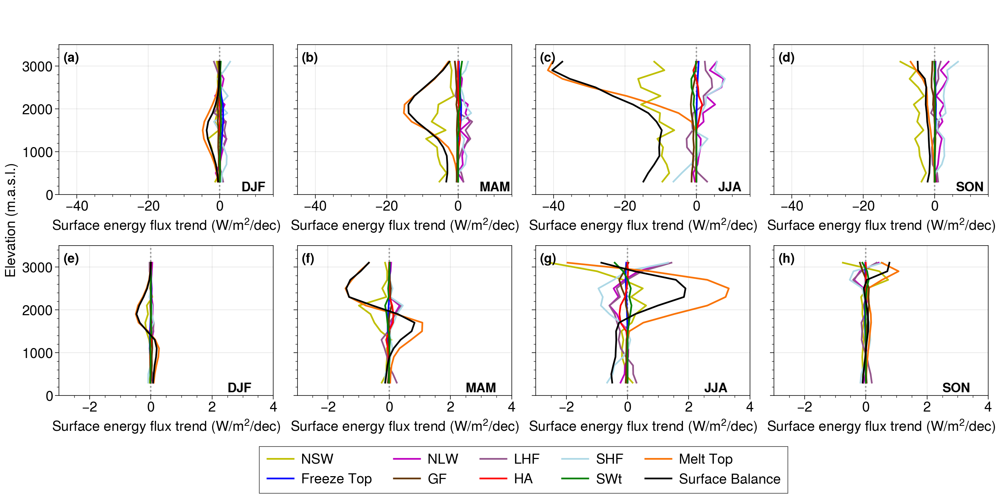

In [73]:
pplt.rc['figure.facecolor'] = 'white'
import string

seasons=['DJF','MAM','JJA','SON']
first_year = 55
last_year = None

# ------------------------ Difference between simulations, mean values ----------------------------

multiplier = 1 # =10 if trends per decade

colors = ['y','m','purple','lightblue','orange','blue','brown','r','green','k']
leg_labels_null = ['','','','','','','','','','']
leg_labels_full = ['NSW','NLW','LHF','SHF','Melt Top','Freeze Top','GF','HA','SWt','Surface Balance']
names_var = ['NSW','NLW','LHF','SHF','melt','freeze','GF','HAcc','SWt','Surf_Bal']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

ds = ds7_Hlev - ds10_Hlev

pplt.rc.update(small=14, large=12)
with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
    f, axs = pplt.subplots(ncols=4,nrows=2,axwidth=3.,axheight=2.1,top=5,sharex=False)

for seas in range(4):
    ax = axs[seas]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds[var].isel(season=seas),H_levels,c=colors[i],label='',linewidth=1.7)

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-45,15)
    ax.format(xlabel='')
    ax.text(6., 75, seasons[seas], fontsize=13,fontweight='semibold')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux (W/$m^2$)'
# Suptitle='Surface energy flux (W/$m^2$)'
#axs.format(abc='a)', abcloc='ul', abcweight='bold', abcsize=12)



# ------------------------ Difference between simulations, trends ----------------------------

multiplier = 10 # =10 if trends per decade

ds = ds7_slopes_Hlev - ds10_slopes_Hlev


for seas in range(4):
    ax = axs[seas+4]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label=leg_labels[seas][i],linewidth=1.7)

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-3,4)
    ax.format(xlabel='')
    ax.text(2.5, 75, seasons[seas], fontsize=13,fontweight='semibold')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux trend (W/$m^2$/dec)'

# ----------------------- Formatting ----------------------------------------

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

f.format(xlabel=xLabel,ylabel='Elevation (m.a.s.l.)')
f.legend(loc='b',prop = { "size": 14 },ncols=5)

/tmp/ipykernel_1599788/1076042983.py:21: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_1599788/1076042983.py:21: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)


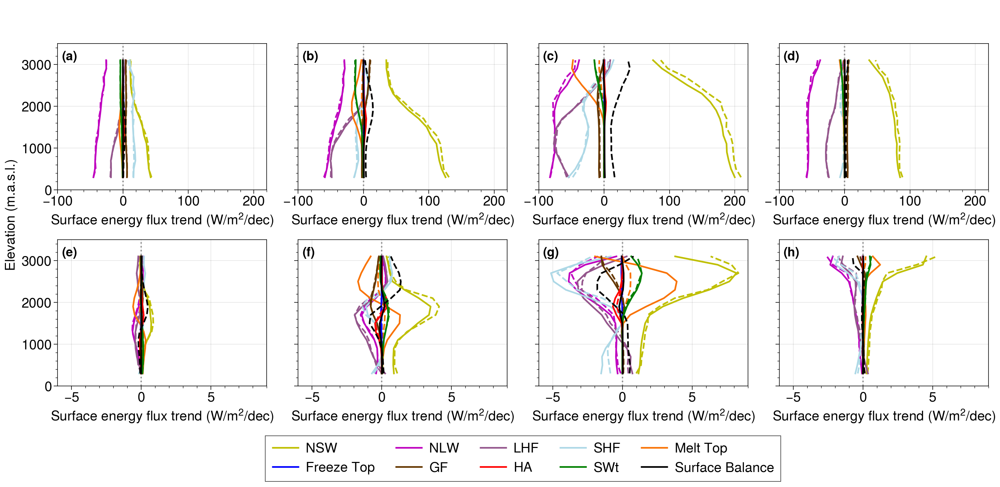

In [75]:
pplt.rc['figure.facecolor'] = 'white'
import string

seasons=['DJF','MAM','JJA','SON']
first_year = 55
last_year = None

# ------------------------ Difference between simulations, mean values ----------------------------

multiplier = 1 # =10 if trends per decade

colors = ['y','m','purple','lightblue','orange','blue','brown','r','green','k']
leg_labels_null = ['','','','','','','','','','']
leg_labels_full = ['NSW','NLW','LHF','SHF','Melt Top','Freeze Top','GF','HA','SWt','Surface Balance']
names_var = ['NSW','NLW','LHF','SHF','melt','freeze','GF','HAcc','SWt','Surf_Bal']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

ds1 = ds7_Hlev
ds2 = ds10_Hlev

pplt.rc.update(small=14, large=12)
with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
    f, axs = pplt.subplots(ncols=4,nrows=2,axwidth=3.,axheight=2.1,top=5,sharex=False)

for seas in range(4):
    ax = axs[seas]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds1[var].isel(season=seas),H_levels,c=colors[i],label='',linewidth=1.7)
        ax.plot(multiplier*ds2[var].isel(season=seas),H_levels,c=colors[i],label='',linewidth=1.7,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-100,220)
    ax.format(xlabel='')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux (W/$m^2$)'
# Suptitle='Surface energy flux (W/$m^2$)'
#axs.format(abc='a)', abcloc='ul', abcweight='bold', abcsize=12)



# ------------------------ Difference between simulations, trends ----------------------------

multiplier = 10 # =10 if trends per decade

ds1 = ds7_slopes_Hlev
ds2 = ds10_slopes_Hlev

for seas in range(4):
    ax = axs[seas+4]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds1[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label=leg_labels[seas][i],linewidth=1.7)
        ax.plot(multiplier*ds2[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label='',linewidth=1.7,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-6,9)
    ax.format(xlabel='')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux trend (W/$m^2$/dec)'

# ----------------------- Formatting ----------------------------------------

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

f.format(xlabel=xLabel,ylabel='Elevation (m.a.s.l.)')
f.legend(loc='b',prop = { "size": 14 },ncols=5)

/tmp/ipykernel_1599788/3703125247.py:11: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_1599788/3703125247.py:11: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)


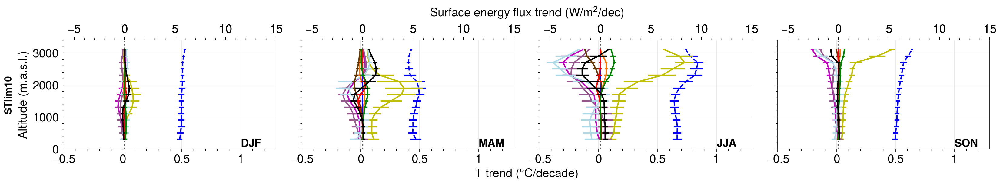

In [80]:
# ------------------------ STlim10 simulation ----------------------------

colors = ['b','y','m','purple','lightblue','orange','blue','brown','r','green','k']
leg_labels_null = ['','','','','','','','','','','']
leg_labels_full = ['TTz','NSW','NLW','LHF','SHF','melt','freeze','GF','HAcc','SWt','Surf_Bal']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

ds_slopes = ds10.polyfit('Year', deg=1)
ds_slopes_Hlev, ds_slopes_Hlev_std = altitude_levels_dataset(ds_slopes,levels=levels_smallish)

pplt.rc.update(small=14, large=12)
with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
    f, axs = pplt.subplots(ncols=4,axwidth=3.5,axheight=1.8)
axs2 = axs.twiny()

for seas in range(4):
    ax = axs[seas]
    ax2 = axs2[seas]
    for i,var in enumerate(leg_labels_full):
        if var=='TTz':
            ax.plot(multiplier*ds_slopes_Hlev[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],linestyle='--',
                    label=leg_labels[seas][i])
        else:
            ax2.plot(multiplier*ds_slopes_Hlev[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label=leg_labels[seas][i])
        for lev in range(len(levels)): # spatial standard deviation
            if var=='TTz':
                slope_var = ds_slopes_Hlev[var+'_polyfit_coefficients'].isel(season=seas,degree=0)[lev]
                std_var = ds_slopes_Hlev_std[var+'_polyfit_coefficients'].isel(season=seas,degree=0)[lev]
                ax.plot([multiplier*(slope_var-std_var),multiplier*(slope_var+std_var)],[H_levels[lev],H_levels[lev]],c=colors[i])
            else:
                slope_var = ds_slopes_Hlev[var+'_polyfit_coefficients'].isel(season=seas,degree=0)[lev]
                std_var = ds_slopes_Hlev_std[var+'_polyfit_coefficients'].isel(season=seas,degree=0)[lev]
                ax2.plot([multiplier*(slope_var-std_var),multiplier*(slope_var+std_var)],[H_levels[lev],H_levels[lev]],c=colors[i])
    ax.set_xlim(-0.5,1.3)
    ax.text(1., 75, seasons[seas], fontsize=13,fontweight='semibold')
    ax.set_ylim(0,3400)
    ax2.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax2.set_xlim(-6,15)
    ax2.format(xlabel='')

#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'T trend (°C/decade)'
Suptitle='Surface energy flux trend (W/$m^2$/dec)'

axs.format(xlabel=xLabel,ylabel='Altitude (m.a.s.l.)',suptitle=Suptitle,rowlabels=['STlim10'])

#### With previously saved data (see script 6-figs_MAR3.14_MPI-smallishdomain.ipynb)

In [21]:
path = '/bettik/castelli/data/saved_data_MAR_MPI_ESM1_2_HR/SSP585/smallishdomain/'
ds_yrs = xr.open_dataset(path + 'ds_Surfbal_vars_seas_2015_2100_MB.npy') #.sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))

ds_yrs

<xarray.Dataset>
Dimensions:     (x: 100, y: 90, ztqlev: 3, sector: 3, Year: 86, season: 4)
Coordinates:
  * x           (x) float32 -370.0 -360.0 -350.0 -340.0 ... 600.0 610.0 620.0
  * y           (y) float32 -440.0 -430.0 -420.0 -410.0 ... 430.0 440.0 450.0
  * ztqlev      (ztqlev) float32 2.0 10.0 100.0
  * sector      (sector) float32 1.0 2.0 3.0
  * season      (season) object 'DJF' 'MAM' 'JJA' 'SON'
  * Year        (Year) int64 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
Data variables: (12/16)
    LWD         (Year, season, y, x) float64 ...
    LWU         (Year, season, y, x) float64 ...
    SWD         (Year, season, y, x) float64 ...
    SWU         (Year, season, y, x) float64 ...
    SHF         (Year, season, y, x) float64 ...
    LHF         (Year, season, y, x) float64 ...
    ...          ...
    melt_top    (Year, season, y, x) float64 ...
    freeze_top  (Year, season, y, x) float64 ...
    NSW         (Year, season, y, x) float64 ...
    NLW         (Year, season, y, x) float64 ...
    Surfbal     (Year, season, y, x) float64 ...
    MB          (Year, season, sector, y, x) float64 ...

In [22]:
path = '/bettik/castelli/data/saved_data_MAR_MPI_ESM1_2_HR/SSP585/smallishdomain/STlim30/'
ds_yrs2 = xr.open_dataset(path + 'ds_Surfbal_vars_seas_2015_2100.npy')

In [23]:
path = '/bettik/castelli/data/saved_data_MAR_MPI_ESM1_2_HR/SSP585/'
ds314_MPI_SSP585 = xr.open_dataset(path + 'ds314_Surfbal_vars_2015_2100_seas.npy')
#.sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))

ds314_MPI_SSP585['Surfbal'] = ds314_MPI_SSP585['NSW'] + ds314_MPI_SSP585['NLW'] + ds314_MPI_SSP585['SHF'] + ds314_MPI_SSP585['LHF'] + ds314_MPI_SSP585['GF'] + \
                                ds314_MPI_SSP585['melt_top'] + ds314_MPI_SSP585['freeze_top'] + ds314_MPI_SSP585['HAcc'] + ds314_MPI_SSP585['SWt']
ds314_MPI_SSP585

<xarray.Dataset>
Dimensions:     (x: 139, y: 91, sector: 3, season: 4, Year: 86, ztqlev: 3,
                 atmlay: 2)
Coordinates:
  * x           (x) float32 -259.0 -252.0 -245.0 -238.0 ... 693.0 700.0 707.0
  * y           (y) float32 -168.0 -161.0 -154.0 -147.0 ... 448.0 455.0 462.0
  * sector      (sector) float32 1.0 2.0 3.0
  * season      (season) object 'DJF' 'MAM' 'JJA' 'SON'
  * Year        (Year) int64 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
  * ztqlev      (ztqlev) float32 2.0 10.0 100.0
  * atmlay      (atmlay) float32 0.9997 0.9995
Data variables: (12/26)
    LWD         (Year, season, y, x) float64 ...
    LWU         (Year, season, y, x) float64 ...
    SWD         (Year, season, y, x) float64 ...
    SWU         (Year, season, y, x) float64 ...
    SHF         (Year, season, y, x) float64 ...
    LHF         (Year, season, y, x) float64 ...
    ...          ...
    MBmTop      (Year, season, sector, y, x) float64 ...
    MBrTop      (Year, season, sector, y, x) float64 ...
    melt_top    (Year, season, y, x) float64 ...
    freeze_top  (Year, season, y, x) float64 ...
    ST          (Year, season, y, x) float64 ...
    Surfbal     (Year, season, y, x) float64 0.5079 0.5227 ... 0.1591 0.155

/tmp/ipykernel_1599788/2234802475.py:11: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_1599788/2234802475.py:11: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)


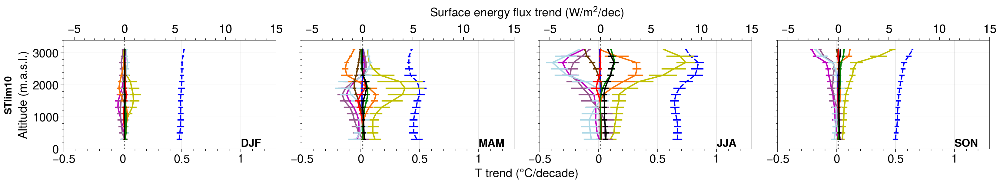

In [84]:
# ------------------------ STlim10 simulation ----------------------------

colors = ['b','y','m','purple','lightblue','orange','blue','brown','r','green','k']
leg_labels_null = ['','','','','','','','','','','']
leg_labels_full = ['TTz','NSW','NLW','LHF','SHF','melt_top','freeze_top','GF','HAcc','SWt','Surfbal']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

ds_slopes = ds_yrs.polyfit('Year', deg=1)
ds_slopes_Hlev, ds_slopes_Hlev_std = altitude_levels_dataset(ds_slopes,levels=levels_smallish)

pplt.rc.update(small=14, large=12)
with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
    f, axs = pplt.subplots(ncols=4,axwidth=3.5,axheight=1.8)
axs2 = axs.twiny()

for seas in range(4):
    ax = axs[seas]
    ax2 = axs2[seas]
    for i,var in enumerate(leg_labels_full):
        if var=='TTz':
            ax.plot(multiplier*ds_slopes_Hlev[var+'_polyfit_coefficients'].isel(ztqlev=0,season=seas,degree=0),H_levels,c=colors[i],linestyle='--',
                    label=leg_labels[seas][i])
        else:
            ax2.plot(multiplier*ds_slopes_Hlev[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label=leg_labels[seas][i])
        for lev in range(len(levels)): # spatial standard deviation
            if var=='TTz':
                slope_var = ds_slopes_Hlev[var+'_polyfit_coefficients'].isel(ztqlev=0,season=seas,degree=0)[lev]
                std_var = ds_slopes_Hlev_std[var+'_polyfit_coefficients'].isel(ztqlev=0,season=seas,degree=0)[lev]
                ax.plot([multiplier*(slope_var-std_var),multiplier*(slope_var+std_var)],[H_levels[lev],H_levels[lev]],c=colors[i])
            else:
                slope_var = ds_slopes_Hlev[var+'_polyfit_coefficients'].isel(season=seas,degree=0)[lev]
                std_var = ds_slopes_Hlev_std[var+'_polyfit_coefficients'].isel(season=seas,degree=0)[lev]
                ax2.plot([multiplier*(slope_var-std_var),multiplier*(slope_var+std_var)],[H_levels[lev],H_levels[lev]],c=colors[i])
    ax.set_xlim(-0.5,1.3)
    ax.text(1., 75, seasons[seas], fontsize=13,fontweight='semibold')
    ax.set_ylim(0,3400)
    ax2.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax2.set_xlim(-6,15)
    ax2.format(xlabel='')

#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'T trend (°C/decade)'
Suptitle='Surface energy flux trend (W/$m^2$/dec)'

axs.format(xlabel=xLabel,ylabel='Altitude (m.a.s.l.)',suptitle=Suptitle,rowlabels=['STlim10'])

In [24]:
ds10_Hlev, ds10_Hlev_std = altitude_levels_dataset(ds_yrs.mean(dim='Year'), levels_smallish)
ds10_Hlev2, ds10_Hlev_std2 = altitude_levels_dataset(ds_yrs2.mean(dim='Year'), levels_smallish)

ds7_Hlev, ds7_Hlev_std = altitude_levels_dataset(ds314_MPI_SSP585.mean(dim='Year'), levels)

In [25]:
ds10_slopes_Hlev, ds10_slopes_Hlev_std = altitude_levels_dataset(ds_yrs.polyfit('Year', deg=1), levels_smallish)
ds10_slopes_Hlev2, ds10_slopes_Hlev_std2 = altitude_levels_dataset(ds_yrs2.polyfit('Year', deg=1), levels_smallish)

ds7_slopes_Hlev, ds7_slopes_Hlev_std = altitude_levels_dataset(ds314_MPI_SSP585.polyfit('Year', deg=1), levels)

/tmp/ipykernel_1599788/808586545.py:20: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=14, large=12)
/tmp/ipykernel_1599788/808586545.py:20: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=14, large=12)


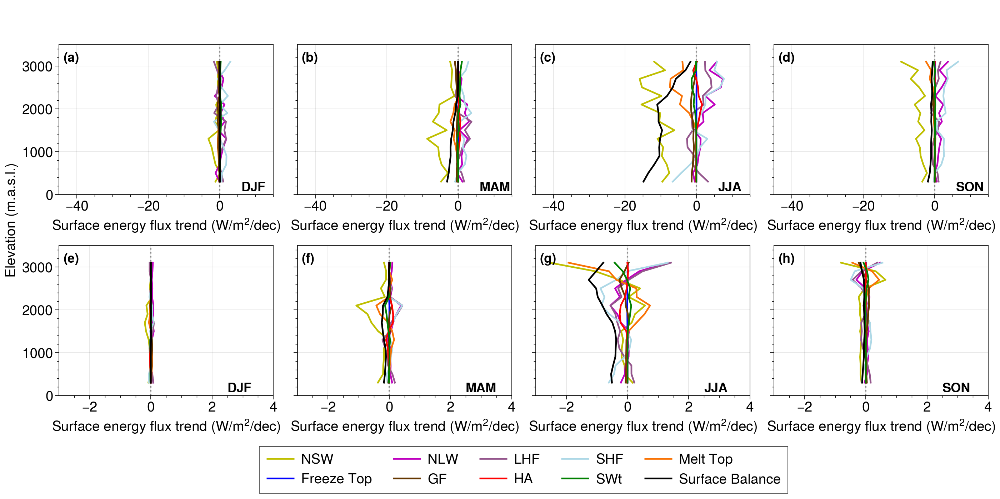

In [132]:
pplt.rc['figure.facecolor'] = 'white'
import string

seasons=['DJF','MAM','JJA','SON']

# ------------------------ Difference between simulations, mean values ----------------------------

multiplier = 1 # =10 if trends per decade

colors = ['y','m','purple','lightblue','orange','blue','brown','r','green','k']
leg_labels_null = ['','','','','','','','','','']
leg_labels_full = ['NSW','NLW','LHF','SHF','Melt Top','Freeze Top','GF','HA','SWt','Surface Balance']
names_var = ['NSW','NLW','LHF','SHF','melt_top','freeze_top','GF','HAcc','SWt','Surfbal']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

ds = ds7_Hlev - ds10_Hlev

pplt.rc.update(small=14, large=12)
with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
    f, axs = pplt.subplots(ncols=4,nrows=2,axwidth=3.,axheight=2.1,top=5,sharex=False)

for seas in range(4):
    ax = axs[seas]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds[var].isel(season=seas),H_levels,c=colors[i],label='',linewidth=1.7)

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-45,15)
    ax.format(xlabel='')
    ax.text(6., 75, seasons[seas], fontsize=13,fontweight='semibold')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux (W/$m^2$)'
# Suptitle='Surface energy flux (W/$m^2$)'
#axs.format(abc='a)', abcloc='ul', abcweight='bold', abcsize=12)



# ------------------------ Difference between simulations, trends ----------------------------

multiplier = 10 # =10 if trends per decade

ds = ds7_slopes_Hlev - ds10_slopes_Hlev


for seas in range(4):
    ax = axs[seas+4]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label=leg_labels[seas][i],linewidth=1.7)

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-3,4)
    ax.format(xlabel='')
    ax.text(2.5, 75, seasons[seas], fontsize=13,fontweight='semibold')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux trend (W/$m^2$/dec)'

# ----------------------- Formatting ----------------------------------------

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

f.format(xlabel=xLabel,ylabel='Elevation (m.a.s.l.)')
f.legend(loc='b',prop = { "size": 14 },ncols=5)
f.save("/summer/mar/castelli/figs/Manuscript/f03_test.png", dpi=300, bbox_inches='tight')

/tmp/ipykernel_105578/921997161.py:19: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=16, large=14)
/tmp/ipykernel_105578/921997161.py:19: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=16, large=14)


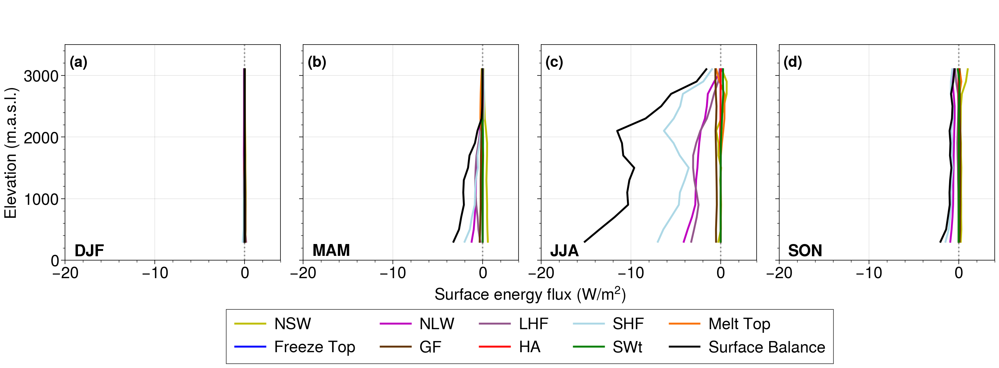

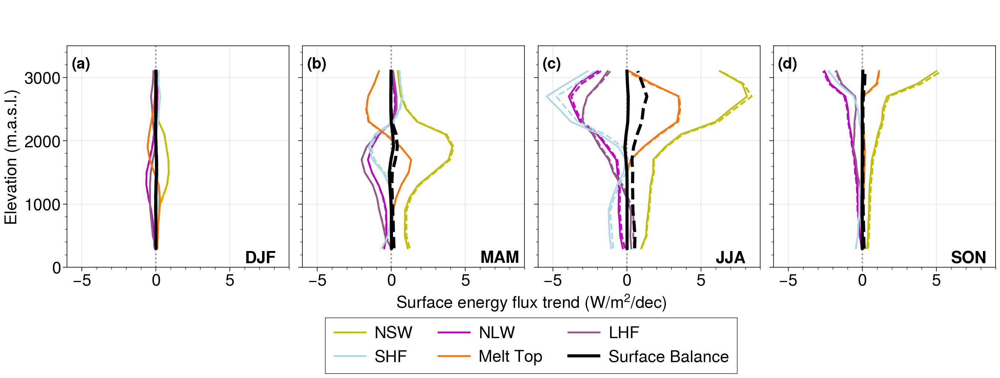

In [36]:
pplt.rc['figure.facecolor'] = 'white'
import string

seasons=['DJF','MAM','JJA','SON']

#--------------------------------------------------------------------------------------------------
# ------------------------ Difference between simulations, mean values ----------------------------

multiplier = 1 # =10 if trends per decade

colors = ['y','m','purple','lightblue','orange','blue','brown','r','green','k']
leg_labels_null = ['','','','','','','','','','']
leg_labels_full = ['NSW','NLW','LHF','SHF','Melt Top','Freeze Top','GF','HA','SWt','Surface Balance']
names_var = ['NSW','NLW','LHF','SHF','melt_top','freeze_top','GF','HAcc','SWt','Surfbal']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

ds = ds10_Hlev2 - ds10_Hlev

pplt.rc.update(small=16, large=14)
with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 16}):
    # f, axs = pplt.subplots(ncols=4,axwidth=3.,axheight=2.1,top=5)
    f, axs = pplt.subplots(ncols=4,axwidth=3.,axheight=3,top=5)

for seas in range(4):
    ax = axs[seas]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds[var].isel(season=seas),H_levels,c=colors[i],label=leg_labels[seas][i],linewidth=1.9)

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-20,4)
    ax.format(xlabel='')
    ax.text(-19., 75, seasons[seas], fontsize=16,fontweight='semibold')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux (W/$m^2$)'
# Suptitle='Surface energy flux (W/$m^2$)'
#axs.format(abc='a)', abcloc='ul', abcweight='bold', abcsize=12)

# ----------------------- Formatting ----------------------------------------

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top', ha='left'
    )

f.format(xlabel=xLabel,ylabel='Elevation (m.a.s.l.)')
f.legend(loc='b',prop = { "size": 16 },ncols=5)
f.save("/summer/mar/castelli/figs/Manuscript/f03.png", dpi=300, bbox_inches='tight')

#--------------------------------------------------------------------------------------------------
# ------------------------ Difference between simulations, trends ----------------------------

colors = ['y','m','purple','lightblue','orange','k']
leg_labels_null = ['','','','','','']
leg_labels_full = ['NSW','NLW','LHF','SHF','Melt Top','Surface Balance']
names_var = ['NSW','NLW','LHF','SHF','melt_top','Surfbal']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

multiplier = 10 # =10 if trends per decade

ds1 = ds10_slopes_Hlev2
ds2 = ds10_slopes_Hlev

with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 16}):
    # f, axs = pplt.subplots(ncols=4,axwidth=3.,axheight=2.1,top=5)
    f, axs = pplt.subplots(ncols=4,axwidth=3.,axheight=3,top=5)

for seas in range(4):
    ax = axs[seas]
    for i,var in enumerate(names_var):
        if var == "Surfbal":
            linewidths = 3.
        else:
            linewidths = 1.7
        ax.plot(multiplier*ds1[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label=leg_labels[seas][i],linewidth=linewidths)
        ax.plot(multiplier*ds2[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label='',linewidth=linewidths,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-6,9)
    ax.format(xlabel='')
    ax.text(6., 75, seasons[seas], fontsize=16,fontweight='semibold')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux trend (W/$m^2$/dec)'

# ----------------------- Formatting ----------------------------------------

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top', ha='left'
    )

f.format(xlabel=xLabel,ylabel='Elevation (m.a.s.l.)')
f.legend(loc='b',prop = { "size": 16 },ncols=3)
f.save("/summer/mar/castelli/figs/Manuscript/f04.png", dpi=300, bbox_inches='tight')


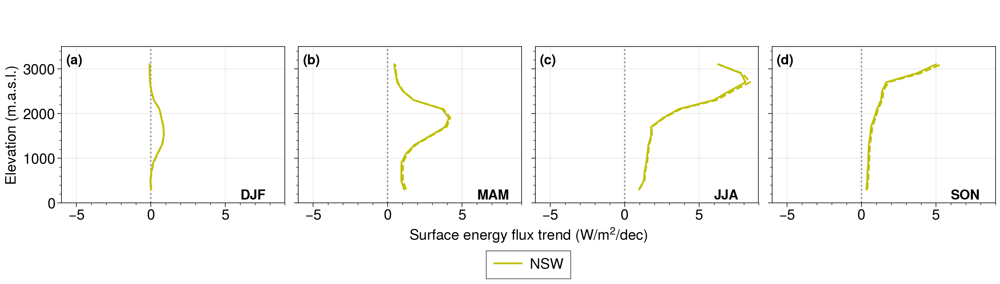

In [45]:
#--------------------------------------------------------------------------------------------------
# ------------------------ Difference between simulations, trends ----------------------------

multiplier = 10 # =10 if trends per decade

colors = ['y','m','purple','lightblue','orange','blue','brown','r','green','k']
leg_labels_null = ['','','','','','','','','','']
leg_labels_full = ['NSW','NLW','LHF','SHF','Melt Top','Freeze Top','GF','HA','SWt','Surface Balance']
names_var = ['NSW','NLW','LHF','SHF','melt_top','freeze_top','GF','HAcc','SWt','Surfbal']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

ds1 = ds10_slopes_Hlev2
ds2 = ds10_slopes_Hlev

with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
    f, axs = pplt.subplots(ncols=4,axwidth=3.,axheight=2.1,top=5)

for seas in range(4):
    ax = axs[seas]
    for i,var in enumerate(names_var):
        if var == "Surfbal":
            linewidths = 3.
        else:
            linewidths = 1.7
        if var == "NSW":
            ax.plot(multiplier*ds1[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label=leg_labels[seas][i],linewidth=linewidths)
            ax.plot(multiplier*ds2[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label='',linewidth=linewidths,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-6,9)
    ax.format(xlabel='')
    ax.text(6., 75, seasons[seas], fontsize=13,fontweight='semibold')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux trend (W/$m^2$/dec)'

# ----------------------- Formatting ----------------------------------------

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

f.format(xlabel=xLabel,ylabel='Elevation (m.a.s.l.)')
f.legend(loc='b',prop = { "size": 14 },ncols=5)

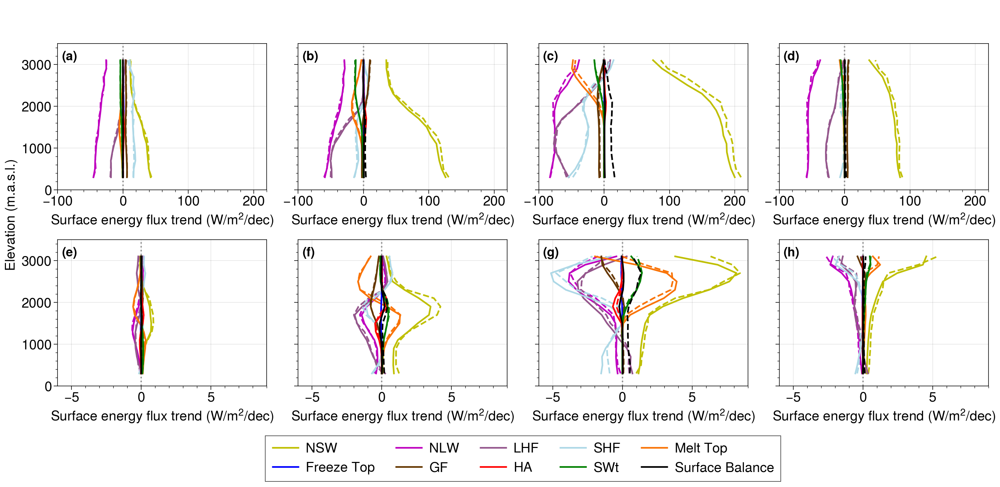

In [133]:
pplt.rc['figure.facecolor'] = 'white'
import string

seasons=['DJF','MAM','JJA','SON']

# ------------------------ Difference between simulations, mean values ----------------------------

multiplier = 1 # =10 if trends per decade

colors = ['y','m','purple','lightblue','orange','blue','brown','r','green','k']
leg_labels_null = ['','','','','','','','','','']
leg_labels_full = ['NSW','NLW','LHF','SHF','Melt Top','Freeze Top','GF','HA','SWt','Surface Balance']
names_var = ['NSW','NLW','LHF','SHF','melt_top','freeze_top','GF','HAcc','SWt','Surfbal']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

ds1 = ds7_Hlev
ds2 = ds10_Hlev

with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
    f, axs = pplt.subplots(ncols=4,nrows=2,axwidth=3.,axheight=2.1,top=5,sharex=False)

for seas in range(4):
    ax = axs[seas]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds1[var].isel(season=seas),H_levels,c=colors[i],label='',linewidth=1.7)
        ax.plot(multiplier*ds2[var].isel(season=seas),H_levels,c=colors[i],label='',linewidth=1.7,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-100,220)
    ax.format(xlabel='')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux (W/$m^2$)'
# Suptitle='Surface energy flux (W/$m^2$)'
#axs.format(abc='a)', abcloc='ul', abcweight='bold', abcsize=12)



# ------------------------ Difference between simulations, trends ----------------------------

multiplier = 10 # =10 if trends per decade

ds1 = ds7_slopes_Hlev
ds2 = ds10_slopes_Hlev

for seas in range(4):
    ax = axs[seas+4]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds1[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label=leg_labels[seas][i],linewidth=1.7)
        ax.plot(multiplier*ds2[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label='',linewidth=1.7,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-6,9)
    ax.format(xlabel='')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux trend (W/$m^2$/dec)'

# ----------------------- Formatting ----------------------------------------

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

f.format(xlabel=xLabel,ylabel='Elevation (m.a.s.l.)')
f.legend(loc='b',prop = { "size": 14 },ncols=5)
f.save("/summer/mar/castelli/figs/Manuscript/f03_test2.png", dpi=300, bbox_inches='tight')

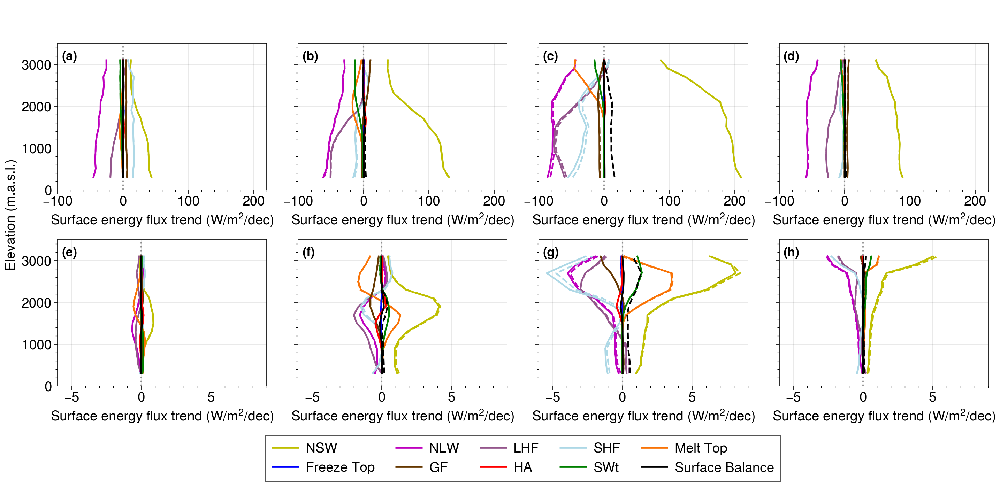

In [141]:
pplt.rc['figure.facecolor'] = 'white'
import string

seasons=['DJF','MAM','JJA','SON']

# ------------------------ Difference between simulations, mean values ----------------------------

multiplier = 1 # =10 if trends per decade

colors = ['y','m','purple','lightblue','orange','blue','brown','r','green','k']
leg_labels_null = ['','','','','','','','','','']
leg_labels_full = ['NSW','NLW','LHF','SHF','Melt Top','Freeze Top','GF','HA','SWt','Surface Balance']
names_var = ['NSW','NLW','LHF','SHF','melt_top','freeze_top','GF','HAcc','SWt','Surfbal']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

ds1 = ds10_Hlev2
ds2 = ds10_Hlev

with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
    f, axs = pplt.subplots(ncols=4,nrows=2,axwidth=3.,axheight=2.1,top=5,sharex=False)

for seas in range(4):
    ax = axs[seas]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds1[var].isel(season=seas),H_levels,c=colors[i],label='',linewidth=1.7)
        ax.plot(multiplier*ds2[var].isel(season=seas),H_levels,c=colors[i],label='',linewidth=1.7,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-100,220)
    ax.format(xlabel='')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux (W/$m^2$)'
# Suptitle='Surface energy flux (W/$m^2$)'
#axs.format(abc='a)', abcloc='ul', abcweight='bold', abcsize=12)



# ------------------------ Difference between simulations, trends ----------------------------

multiplier = 10 # =10 if trends per decade

ds1 = ds10_slopes_Hlev2
ds2 = ds10_slopes_Hlev

for seas in range(4):
    ax = axs[seas+4]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds1[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label=leg_labels[seas][i],linewidth=1.7)
        ax.plot(multiplier*ds2[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label='',linewidth=1.7,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-6,9)
    ax.format(xlabel='')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux trend (W/$m^2$/dec)'

# ----------------------- Formatting ----------------------------------------

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

f.format(xlabel=xLabel,ylabel='Elevation (m.a.s.l.)')
f.legend(loc='b',prop = { "size": 14 },ncols=5)

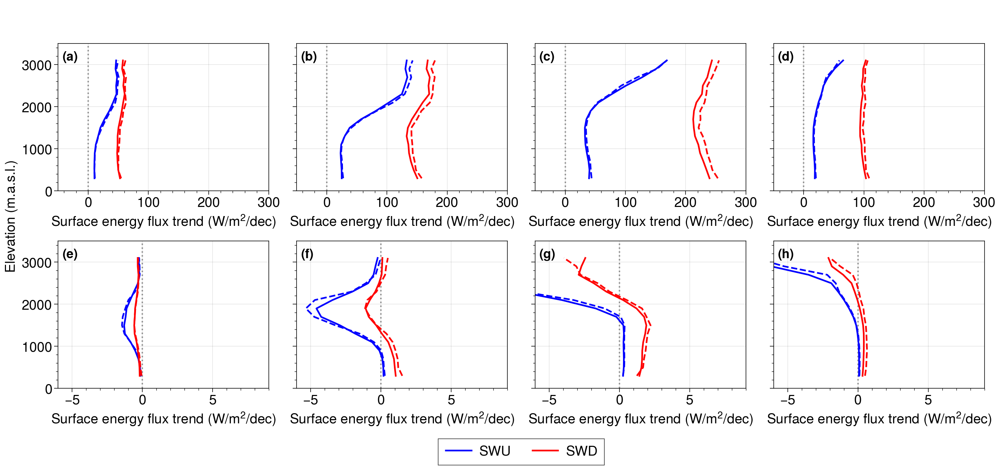

In [135]:
pplt.rc['figure.facecolor'] = 'white'
import string

seasons=['DJF','MAM','JJA','SON']

# ------------------------ Difference between simulations, mean values ----------------------------

multiplier = 1 # =10 if trends per decade

colors = ['b','r']
leg_labels_null = ['','',]
leg_labels_full = ['SWU','SWD']
names_var = ['SWU','SWD']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

ds1 = ds7_Hlev
ds2 = ds10_Hlev

with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
    f, axs = pplt.subplots(ncols=4,nrows=2,axwidth=3.,axheight=2.1,top=5,sharex=False)

for seas in range(4):
    ax = axs[seas]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds1[var].isel(season=seas),H_levels,c=colors[i],label='',linewidth=1.7)
        ax.plot(multiplier*ds2[var].isel(season=seas),H_levels,c=colors[i],label='',linewidth=1.7,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-50,300)
    ax.format(xlabel='')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux (W/$m^2$)'
# Suptitle='Surface energy flux (W/$m^2$)'
#axs.format(abc='a)', abcloc='ul', abcweight='bold', abcsize=12)



# ------------------------ Difference between simulations, trends ----------------------------

multiplier = 10 # =10 if trends per decade

ds1 = ds7_slopes_Hlev
ds2 = ds10_slopes_Hlev

for seas in range(4):
    ax = axs[seas+4]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds1[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label=leg_labels[seas][i],linewidth=1.7)
        ax.plot(multiplier*ds2[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label='',linewidth=1.7,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-6,9)
    ax.format(xlabel='')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux trend (W/$m^2$/dec)'

# ----------------------- Formatting ----------------------------------------

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

f.format(xlabel=xLabel,ylabel='Elevation (m.a.s.l.)')
f.legend(loc='b',prop = { "size": 14 },ncols=5)

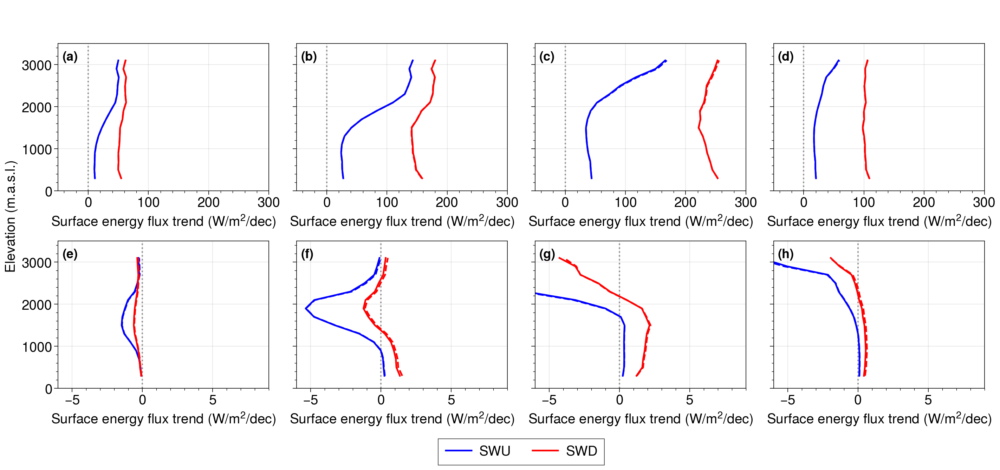

In [140]:
pplt.rc['figure.facecolor'] = 'white'
import string

seasons=['DJF','MAM','JJA','SON']

# ------------------------ Difference between simulations, mean values ----------------------------

multiplier = 1 # =10 if trends per decade

colors = ['b','r']
leg_labels_null = ['','',]
leg_labels_full = ['SWU','SWD']
names_var = ['SWU','SWD']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

ds1 = ds10_Hlev2
ds2 = ds10_Hlev

with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
    f, axs = pplt.subplots(ncols=4,nrows=2,axwidth=3.,axheight=2.1,top=5,sharex=False)

for seas in range(4):
    ax = axs[seas]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds1[var].isel(season=seas),H_levels,c=colors[i],label='',linewidth=1.7)
        ax.plot(multiplier*ds2[var].isel(season=seas),H_levels,c=colors[i],label='',linewidth=1.7,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-50,300)
    ax.format(xlabel='')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux (W/$m^2$)'
# Suptitle='Surface energy flux (W/$m^2$)'
#axs.format(abc='a)', abcloc='ul', abcweight='bold', abcsize=12)



# ------------------------ Difference between simulations, trends ----------------------------

multiplier = 10 # =10 if trends per decade

ds1 = ds10_slopes_Hlev2
ds2 = ds10_slopes_Hlev

for seas in range(4):
    ax = axs[seas+4]
    for i,var in enumerate(names_var):
        ax.plot(multiplier*ds1[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label=leg_labels[seas][i],linewidth=1.7)
        ax.plot(multiplier*ds2[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label='',linewidth=1.7,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-6,9)
    ax.format(xlabel='')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux trend (W/$m^2$/dec)'

# ----------------------- Formatting ----------------------------------------

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

f.format(xlabel=xLabel,ylabel='Elevation (m.a.s.l.)')
f.legend(loc='b',prop = { "size": 14 },ncols=5)

### How do trends compensate with relaxed limiter

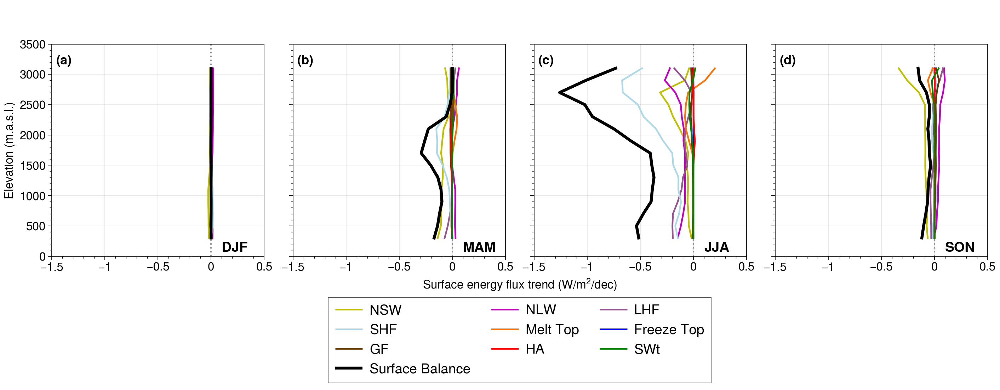

In [30]:
pplt.rc['figure.facecolor'] = 'white'
import string

seasons=['DJF','MAM','JJA','SON']
#--------------------------------------------------------------------------------------------------
# ------------------------ Difference between simulations, trends ----------------------------

# colors = ['y','m','purple','lightblue','orange','k']
# leg_labels_null = ['','','','','','']
# leg_labels_full = ['NSW','NLW','LHF','SHF','Melt Top','Surface Balance']
# names_var = ['NSW','NLW','LHF','SHF','melt_top','Surfbal']
# leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

colors = ['y','m','purple','lightblue','orange','blue','brown','r','green','k']
leg_labels_null = ['','','','','','','','','','']
leg_labels_full = ['NSW','NLW','LHF','SHF','Melt Top','Freeze Top','GF','HA','SWt','Surface Balance']
names_var = ['NSW','NLW','LHF','SHF','melt_top','freeze_top','GF','HAcc','SWt','Surfbal']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

multiplier = 10 # =10 if trends per decade

# ds1 = ds10_slopes_Hlev2
# ds2 = ds10_slopes_Hlev
ds = ds10_slopes_Hlev2 - ds10_slopes_Hlev

with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
    # f, axs = pplt.subplots(ncols=4,axwidth=3.,axheight=2.1,top=5)
    f, axs = pplt.subplots(ncols=4,axwidth=3.,axheight=3,top=5)

for seas in range(4):
    ax = axs[seas]
    for i,var in enumerate(names_var):
        if var == "Surfbal":
            linewidths = 3.
        else:
            linewidths = 1.7
        ax.plot(multiplier*ds[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label=leg_labels[seas][i],linewidth=linewidths)
        # ax.plot(multiplier*ds2[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label='',linewidth=linewidths,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-1.5,0.5)
    ax.format(xlabel='')
    ax.text(0.1, 75, seasons[seas], fontsize=14,fontweight='semibold')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux trend (W/$m^2$/dec)'

# ----------------------- Formatting ----------------------------------------

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

f.format(xlabel=xLabel,ylabel='Elevation (m.a.s.l.)')
f.legend(loc='b',prop = { "size": 14 },ncols=3)
# f.save("/summer/mar/castelli/figs/Manuscript/f04.png", dpi=300, bbox_inches='tight')


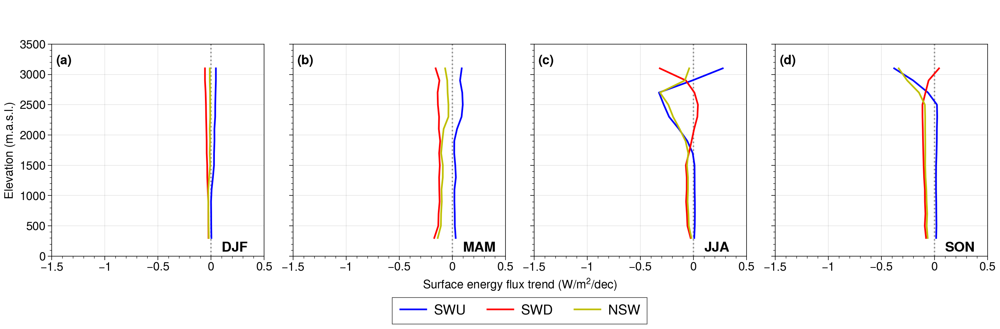

In [34]:
pplt.rc['figure.facecolor'] = 'white'
import string

seasons=['DJF','MAM','JJA','SON']
#--------------------------------------------------------------------------------------------------
# ------------------------ Difference between 10 km simulations for shortwave, trends ----------------------------

# colors = ['y','m','purple','lightblue','orange','k']
# leg_labels_null = ['','','','','','']
# leg_labels_full = ['NSW','NLW','LHF','SHF','Melt Top','Surface Balance']
# names_var = ['NSW','NLW','LHF','SHF','melt_top','Surfbal']
# leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

colors = ['b','r','y']
leg_labels_null = ['','','']
leg_labels_full = ['SWU','SWD','NSW']
names_var = ['SWU','SWD','NSW']
leg_labels = [leg_labels_full,leg_labels_null,leg_labels_null,leg_labels_null]

multiplier = 10 # =10 if trends per decade

# ds1 = ds10_slopes_Hlev2
# ds2 = ds10_slopes_Hlev
ds = ds10_slopes_Hlev2 - ds10_slopes_Hlev
ds['SWU_polyfit_coefficients'] = -ds['SWU_polyfit_coefficients']

with pplt.rc.context({'suptitle.weight': 'normal', 'suptitle.size': 14}):
    # f, axs = pplt.subplots(ncols=4,axwidth=3.,axheight=2.1,top=5)
    f, axs = pplt.subplots(ncols=4,axwidth=3.,axheight=3,top=5)

for seas in range(4):
    ax = axs[seas]
    for i,var in enumerate(names_var):
        if var == "Surfbal":
            linewidths = 3.
        else:
            linewidths = 1.7
        ax.plot(multiplier*ds[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label=leg_labels[seas][i],linewidth=linewidths)
        # ax.plot(multiplier*ds2[var+'_polyfit_coefficients'].isel(season=seas,degree=0),H_levels,c=colors[i],label='',linewidth=linewidths,linestyle='--')

    ax.vlines(0,0,3500,c='k',linestyle=':',alpha=0.4)
    ax.set_xlim(-1.5,0.5)
    ax.format(xlabel='')
    ax.text(0.1, 75, seasons[seas], fontsize=14,fontweight='semibold')

# f.text(0.5, 0.9, "Surface energy flux (W/$m^2$)",
#          ha="center", va="bottom",size=14)
#f.legend(loc='b',prop = { "size": 14 },ncols=4)
xLabel = 'Surface energy flux trend (W/$m^2$/dec)'

# ----------------------- Formatting ----------------------------------------

# Add manual subplot labels (a–h, for example)
letters = list(string.ascii_lowercase)  # ['a','b','c',...]
labels = letters[:len(axs)]  # e.g. ['a','b','c','d'] or ['e','f','g','h']

# You can offset starting letter manually (e.g. start at 'e')
start_index = 0  # 0-based, so 4 = 'e'
labels = letters[start_index:start_index+len(axs)]

for i, ax in enumerate(axs):
    ax.text(
        0.02, 0.95, f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        va='top', ha='left'
    )

f.format(xlabel=xLabel,ylabel='Elevation (m.a.s.l.)')
f.legend(loc='b',prop = { "size": 14 },ncols=3)
# f.save("/summer/mar/castelli/figs/Manuscript/f04.png", dpi=300, bbox_inches='tight')


### Test

In [68]:
path = '/bettik/castelli/data/saved_data_MAR_MPI_ESM1_2_HR/SSP585/smallishdomain/'
ds_yrs = xr.open_dataset(path + 'ds_Surfbal_vars_seas_2015_2100_MB.npy') #.sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))

ds_yrs

<xarray.Dataset>
Dimensions:     (x: 100, y: 90, ztqlev: 3, sector: 3, Year: 86, season: 4)
Coordinates:
  * x           (x) float32 -370.0 -360.0 -350.0 -340.0 ... 600.0 610.0 620.0
  * y           (y) float32 -440.0 -430.0 -420.0 -410.0 ... 430.0 440.0 450.0
  * ztqlev      (ztqlev) float32 2.0 10.0 100.0
  * sector      (sector) float32 1.0 2.0 3.0
  * season      (season) object 'DJF' 'MAM' 'JJA' 'SON'
  * Year        (Year) int64 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
Data variables: (12/16)
    LWD         (Year, season, y, x) float64 ...
    LWU         (Year, season, y, x) float64 ...
    SWD         (Year, season, y, x) float64 ...
    SWU         (Year, season, y, x) float64 ...
    SHF         (Year, season, y, x) float64 ...
    LHF         (Year, season, y, x) float64 ...
    ...          ...
    melt_top    (Year, season, y, x) float64 ...
    freeze_top  (Year, season, y, x) float64 ...
    NSW         (Year, season, y, x) float64 ...
    NLW         (Year, season, y, x) float64 ...
    Surfbal     (Year, season, y, x) float64 ...
    MB          (Year, season, sector, y, x) float64 ...

In [18]:
path = '/bettik/castelli/data/saved_data_MAR_MPI_ESM1_2_HR/SSP585/smallishdomain/STlim30/'
ds_yrs2 = xr.open_dataset(path + 'ds_Surfbal_vars_seas_2015_2100.npy')

ds_yrs2

<xarray.Dataset>
Dimensions:     (x: 100, y: 90, ztqlev: 3, sector: 3, atmlay: 2, Year: 86,
                 season: 4)
Coordinates:
  * x           (x) float32 -370.0 -360.0 -350.0 -340.0 ... 600.0 610.0 620.0
  * y           (y) float32 -440.0 -430.0 -420.0 -410.0 ... 430.0 440.0 450.0
  * ztqlev      (ztqlev) float32 2.0 10.0 100.0
  * sector      (sector) float32 1.0 2.0 3.0
  * atmlay      (atmlay) float32 0.9997 0.9995
  * season      (season) object 'DJF' 'MAM' 'JJA' 'SON'
  * Year        (Year) int64 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
Data variables: (12/18)
    LWD         (Year, season, y, x) float64 ...
    LWU         (Year, season, y, x) float64 ...
    SWD         (Year, season, y, x) float64 ...
    SWU         (Year, season, y, x) float64 ...
    SHF         (Year, season, y, x) float64 ...
    LHF         (Year, season, y, x) float64 ...
    ...          ...
    TTmax       (Year, season, atmlay, y, x) float64 ...
    melt_top    (Year, season, y, x) float64 ...
    freeze_top  (Year, season, y, x) float64 ...
    NSW         (Year, season, y, x) float64 ...
    NLW         (Year, season, y, x) float64 ...
    Surfbal     (Year, season, y, x) float64 ...

In [19]:
def plot_monthly_2points(ds_var,x_axis,first,last,iloc1,jloc1,iloc2,jloc2,ymin,ymax,names_var,colors,titleoffig):
# ------------------------------------------------- Map ------------------------------------------------
        
    colors_land = plt.cm.terrain(np.linspace(0.25, 1, 256))
    f, ax = pplt.subplots(proj='cyl', axwidth=5)
    m=ax.pcolormesh(ds_smallish.LON, ds_smallish.LAT, ds_smallish.SH, levels=17,cmap=colors_land)
    f.colorbar(m,label= 'm.a.s.l.',labelsize='large',ticklabelsize='large')

    ax.plot(ds_smallish.LON[iloc1,jloc1], ds_smallish.LAT[iloc1,jloc1],'rx',markersize=8,markeredgewidth=1.5)
    ax.plot(ds_smallish.LON[iloc2,jloc2], ds_smallish.LAT[iloc2,jloc2],'bx',markersize=8,markeredgewidth=1.5)

    ax.format(**normal_format)
    ax.format(ocean=True,oceancolor='royalblue',reso='hi')

# ------------------------------------------------- Time series plots ------------------------------------------------

    #longitude_point = round(float(lon[iloc,jloc]),2)
    #latitude_point = round(float(lat[iloc,jloc]),2)
    f, axs = pplt.subplots(axwidth=5,axheight=0.4,ncols=2,nrows=2,hratios=(1,5),ref=1,sharey=False)
    pplt.rc.update(small=10, large=12)
    
    #ds_var_ave['Surf_Bal_HA_col'] = ds_var_ave.NSW + ds_var_ave.NLW + ds_var_ave.SHF + ds_var_ave.LHF + ds_var_ave.melt + ds_var_ave.freeze + ds_var_ave.HA_col
    #ds_var['Surf_Bal_HA_colk'] = ds_var.NSWk + ds_var.NLWk + ds_var.SHFk + ds_var.LHFk + ds_var.meltk + ds_var.freezek + ds_var.HA_colk

    for i,var in enumerate(names_var):
        if(var=='Surf_Bal' or var=='Surf_Bal_HA_col' or var=='Surfbal'):
            line_width=2.5
        else:
            line_width=1
        ax=axs[2]
        ax.set_ylim([ymin,ymax])
        ax.format(ylabel='W/$m^2$')
        ax.scatter(x_axis[first:last], np.array(ds_var[var])[first:last,iloc1,jloc1], c=colors[i], s=10)
        ax.plot(x_axis[first:last], np.array(ds_var[var])[first:last,iloc1,jloc1], c=colors[i],linewidth=line_width)
        
        ax=axs[3]
        ax.set_ylim([ymin,ymax])
        ax.scatter(x_axis[first:last], np.array(ds_var[var])[first:last,iloc2,jloc2], c=colors[i], s=10)
        ax.plot(x_axis[first:last], np.array(ds_var[var])[first:last,iloc2,jloc2], c=colors[i],linewidth=line_width,label=var)


    max_MB = max(np.array(ds_var['MB'])[first:last,:,iloc1,jloc1].max(), np.array(ds_var['MB'])[:,first:last,iloc2,jloc2].max())
    ax=axs[0]
    ax.format(title='Point 1 (red)',ylabel='Snow \n(mmWe)')
    ax.set_ylim([-0.1,max_MB])
    ax.plot(x_axis[first:last], np.array(ds_var['MB'].max(axis=1))[first:last,iloc1,jloc1], c='skyblue',linewidth=line_width)

    max_MB = np.array(ds_var['MB'])[first:last,:,iloc2,jloc2].max()
    ax=axs[1]
    ax.format(title='Point 2 (blue)')
    ax.plot(x_axis[first:last], np.array(ds_var['MB'].max(axis=1))[first:last,iloc2,jloc2], c='skyblue',linewidth=line_width)

    #f.format(titlesize='20px',suptitle=f'Gridpoint (lon {longitude_point}°, lat {latitude_point}°)')
    f.legend(loc='b',prop = { "size": 10 },ncols=4)
    f.format(suptitle=titleoffig)

/home/castelli/.conda/envs/phd_v5/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/tmp/ipykernel_644814/2383739220.py:20: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=10, large=12)
/tmp/ipykernel_644814/2383739220.py:20: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=10, large=12)


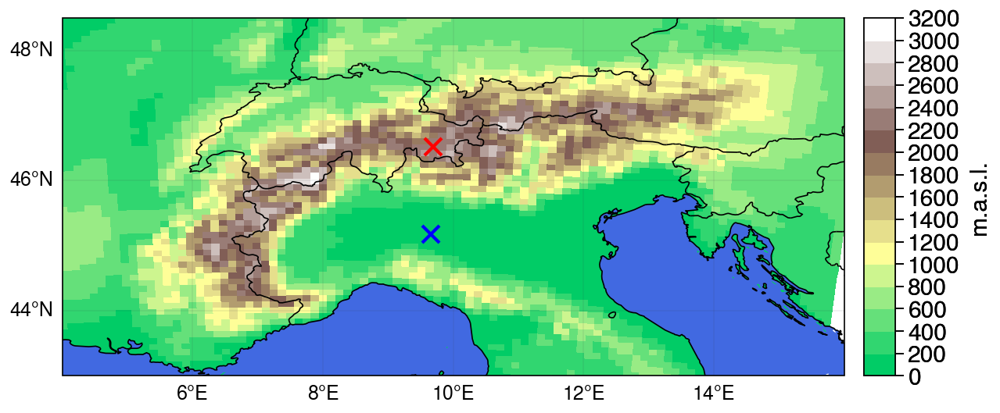

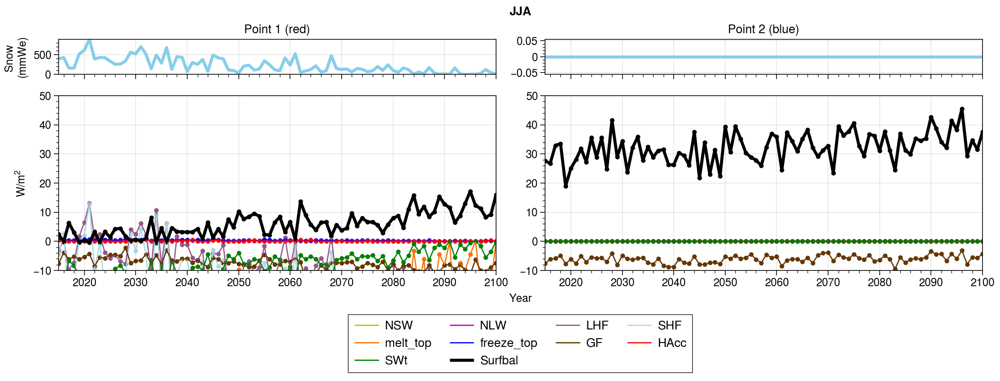

In [20]:
plot_monthly_2points(ds_yrs.sel(season='JJA'), x_axis=ds_yrs.Year, first=0, last=None, iloc1=50, jloc1=50, iloc2=35, jloc2=50, ymin=-10, ymax=50,
                     names_var = ['NSW','NLW','LHF','SHF','melt_top','freeze_top','GF','HAcc','SWt','Surfbal'],
                     colors = ['y','m','purple','lightblue','orange','blue','brown','r','green','k'],titleoffig='JJA')

/home/castelli/.conda/envs/phd_v5/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/tmp/ipykernel_644814/2383739220.py:20: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=10, large=12)
/tmp/ipykernel_644814/2383739220.py:20: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=10, large=12)


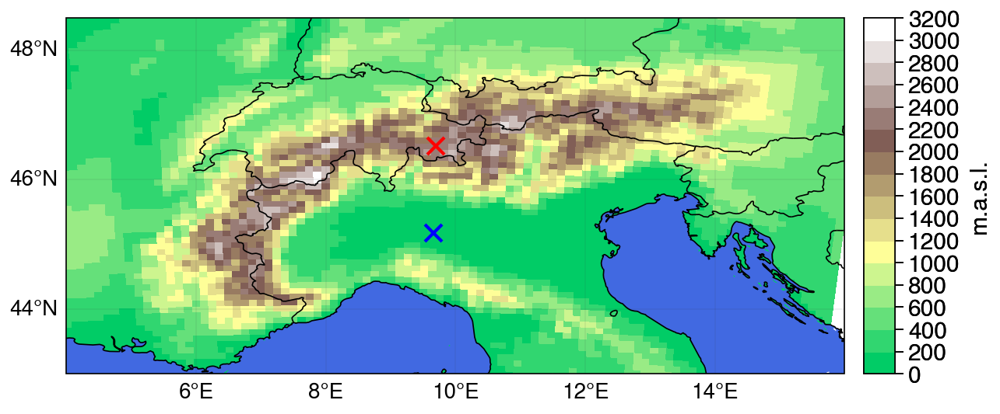

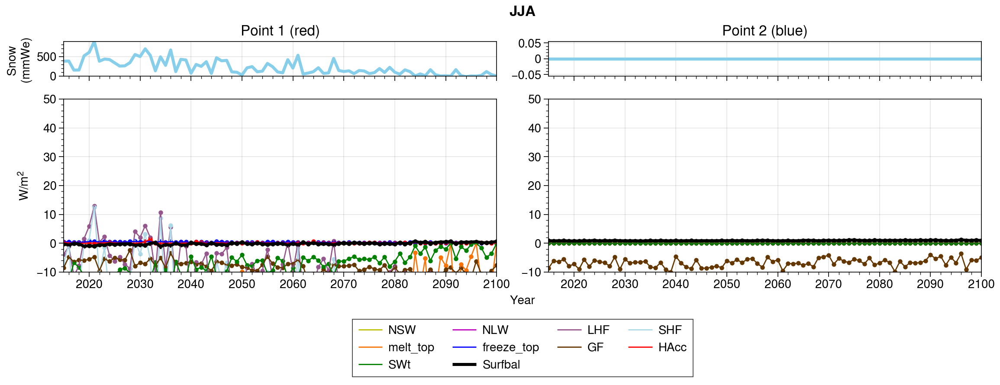

In [21]:
plot_monthly_2points(ds_yrs2.sel(season='JJA'), x_axis=ds_yrs2.Year, first=0, last=None, iloc1=50, jloc1=50, iloc2=35, jloc2=50, ymin=-10, ymax=50,
                     names_var = ['NSW','NLW','LHF','SHF','melt_top','freeze_top','GF','HAcc','SWt','Surfbal'],
                     colors = ['y','m','purple','lightblue','orange','blue','brown','r','green','k'],titleoffig='JJA')

In [22]:
ds_yrs_alps = ds_yrs.where(alps_smallish).mean(dim=('x','y'))
ds_yrs2_alps = ds_yrs2.where(alps_smallish).mean(dim=('x','y'))


In [23]:
var = 'NSW'
ds_yrs2_alps.sel(season='JJA')[var]

<xarray.DataArray 'NSW' (Year: 86)>
array([194.85230702, 168.53422375, 188.09381301, 181.89924565,
       149.42456169, 169.72814575, 176.21178288, 196.97684334,
       176.17081743, 202.39861067, 174.76151663, 194.02605655,
       181.65066707, 185.51376357, 181.97177196, 176.10170885,
       159.54891377, 200.6032203 , 194.20930541, 163.47614758,
       186.52997231, 169.69801452, 186.55812579, 197.12828732,
       177.9422073 , 182.81771423, 185.70369978, 179.90789577,
       178.81083821, 193.61538265, 175.11626661, 200.83471746,
       167.30384836, 191.24154634, 165.89610934, 202.42877514,
       186.05636352, 202.35136323, 202.44902744, 198.90703737,
       168.21197284, 194.69786896, 187.19284171, 185.93520999,
       189.33405823, 202.19796073, 177.27176253, 214.66674891,
       194.32650616, 188.3621104 , 189.51862613, 200.4217638 ,
       199.24834536, 181.90243654, 189.75691828, 179.05203064,
       167.71456404, 200.8306026 , 187.45014324, 203.08846906,
       192.73899787, 193.98557443, 180.93500482, 180.99187614,
       204.5058876 , 185.11856813, 191.88018036, 185.16260021,
       193.25929361, 211.31934105, 200.69972822, 202.68349474,
       199.2554806 , 195.85237231, 204.95622861, 193.19850979,
       190.6507811 , 186.36785404, 180.1087533 , 202.10824186,
       209.88110458, 190.70175447, 192.43099639, 200.2511965 ,
       190.41107444, 206.67383317])
Coordinates:
    season   <U3 'JJA'
  * Year     (Year) int64 2015 2016 2017 2018 2019 ... 2096 2097 2098 2099 2100

/tmp/ipykernel_644814/3064974141.py:12: ProplotWarning: rc setting 'small' was renamed to 'font.smallsize' in version 0.6.
  pplt.rc.update(small=10, large=12)
/tmp/ipykernel_644814/3064974141.py:12: ProplotWarning: rc setting 'large' was renamed to 'font.largesize' in version 0.6.
  pplt.rc.update(small=10, large=12)


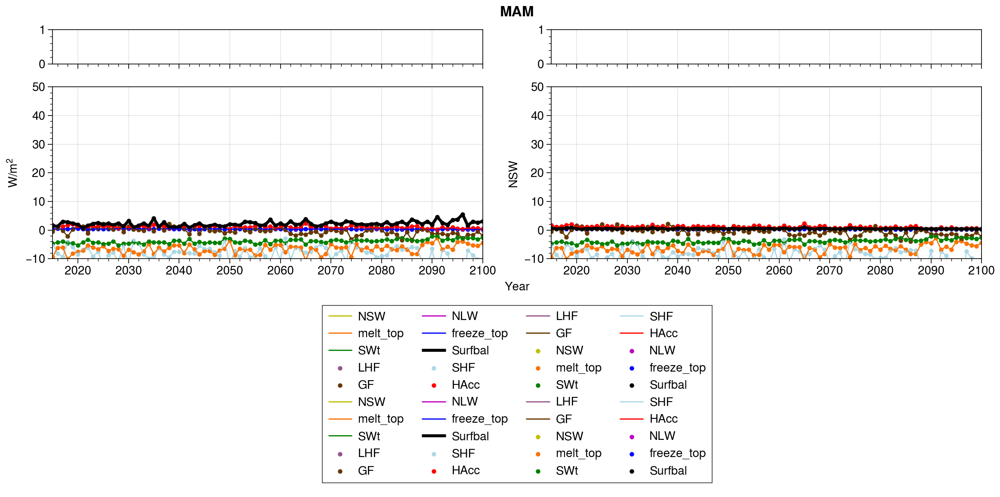

In [36]:
x_axis=ds_yrs.Year
first=0
last=None
ymin=-10
ymax=50
names_var = ['NSW','NLW','LHF','SHF','melt_top','freeze_top','GF','HAcc','SWt','Surfbal']
colors = ['y','m','purple','lightblue','orange','blue','brown','r','green','k']
seas='MAM'


f, axs = pplt.subplots(axwidth=5,axheight=0.4,ncols=2,nrows=2,hratios=(1,5),ref=1,sharey=False)
pplt.rc.update(small=10, large=12)

for i,var in enumerate(names_var):
    if(var=='Surf_Bal' or var=='Surf_Bal_HA_col' or var=='Surfbal'):
        line_width=2.5
    else:
        line_width=1
    ax=axs[2]
    ax.set_ylim([ymin,ymax])
    ax.format(ylabel='W/$m^2$')
    ax.scatter(x_axis[first:last], ds_yrs_alps.sel(season=seas)[var], c=colors[i], s=10)
    ax.plot(x_axis[first:last], ds_yrs_alps.sel(season=seas)[var], c=colors[i],linewidth=line_width)
    
    ax=axs[3]
    ax.set_ylim([ymin,ymax])
    ax.scatter(x_axis[first:last], ds_yrs2_alps.sel(season=seas)[var], c=colors[i], s=10)
    ax.plot(x_axis[first:last], ds_yrs2_alps.sel(season=seas)[var], c=colors[i],linewidth=line_width,label=var)


# max_MB = max(np.array(ds_var['MB'])[first:last,:,iloc1,jloc1].max(), np.array(ds_var['MB'])[:,first:last,iloc2,jloc2].max())
# ax=axs[0]
# ax.format(title='Point 1 (red)',ylabel='Snow \n(mmWe)')
# ax.set_ylim([-0.1,max_MB])
# ax.plot(x_axis[first:last], np.array(ds_var['MB'].max(axis=1))[first:last,iloc1,jloc1], c='skyblue',linewidth=line_width)

# max_MB = np.array(ds_var['MB'])[first:last,:,iloc2,jloc2].max()
# ax=axs[1]
# ax.format(title='Point 2 (blue)')
# ax.plot(x_axis[first:last], np.array(ds_var['MB'].max(axis=1))[first:last,iloc2,jloc2], c='skyblue',linewidth=line_width)

#f.format(titlesize='20px',suptitle=f'Gridpoint (lon {longitude_point}°, lat {latitude_point}°)')
f.legend(loc='b',prop = { "size": 10 },ncols=4)
f.format(suptitle=seas)

In [28]:
ds_yrs_alps.sel(season='JJA')[var]

<xarray.Dataset>
Dimensions:     (Year: 86)
Coordinates:
    season      <U3 'JJA'
  * Year        (Year) int64 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
Data variables:
    NSW         (Year) float64 194.2 168.2 188.3 182.1 ... 200.7 191.2 207.6
    NLW         (Year) float64 -77.85 -67.66 -77.4 ... -82.39 -74.1 -85.28
    LHF         (Year) float64 -64.65 -58.05 -59.94 ... -61.18 -67.32 -59.45
    SHF         (Year) float64 -25.81 -21.93 -29.2 ... -33.36 -28.6 -40.44
    melt_top    (Year) float64 -5.544 -5.381 -3.253 ... -1.757 -1.408 -0.2821
    freeze_top  (Year) float64 0.055 0.06368 0.03242 ... 0.007728 0.00196
    GF          (Year) float64 -8.716 -6.726 -6.55 ... -7.469 -6.735 -6.719
    HAcc        (Year) float64 0.897 0.3969 0.2134 ... 0.09268 0.06073 0.01199
    SWt         (Year) float64 -1.315 -1.606 -0.8167 ... -0.2757 -0.05833
    Surfbal     (Year) float64 11.22 7.302 11.38 10.98 ... 14.3 12.83 15.41

In [29]:
var

['NSW',
 'NLW',
 'LHF',
 'SHF',
 'melt_top',
 'freeze_top',
 'GF',
 'HAcc',
 'SWt',
 'Surfbal']